# EvidenceMem v4 UIE-22K: frozen confirmatory evaluation

This notebook is the one-shot confirmatory run created after the development
experiment selected `siglip2_b16_384`. It evaluates only that encoder on the
untouched 3,300-image confirmatory split. The data manifest, package tree,
method, 40-image-per-class budget, seeds, and hypotheses are hard frozen.

**Primary hypothesis.** EvidenceMem at 40 stored images per class is
non-inferior to full kNN at a predeclared one-percentage-point margin while
using 30 times fewer stored images.

**Secondary hypothesis.** Reliability-aware continuous fusion is more
accurate than the equal-count facility-selection baseline. A failed
hypothesis remains a valid confirmatory result and must not trigger tuning.


## Before running on Kaggle

1. Create a new Kaggle notebook from this file. Do not edit its configuration.
2. Select a **GPU T4** accelerator and turn **Internet on**.
3. Add the dataset
   `rhtsingh/130k-images-512x512-universal-image-embeddings`.
4. Optionally add the successful development notebook as an input so verified
   SigLIP2 train/validation caches can be reused. Confirmatory embeddings are
   always computed from the untouched confirmatory split.
5. Use **Run All once**. Do not tune any setting after reading these results.
6. Download the final ZIP. It contains the frozen protocol, raw predictions,
   paired tests, hierarchical confidence intervals, and file hashes.

The notebook refuses to run if the manifest, package implementation, encoder,
method, budget, sample seed, or five stochastic seeds differ from the frozen
development record.


In [1]:
# Robust bootstrap: use a local checkout when present, otherwise clone the verified branch.
import base64
import importlib.util
import os
import subprocess
import sys
from importlib import metadata as importlib_metadata
from pathlib import Path

from packaging.requirements import Requirement

REPOSITORY_URL = "https://github.com/Prathmesh333/evidencemem.git"
# Immutable tag created for the confirmatory protocol. Do not override it.
REPOSITORY_REF = "uie22k-v4-confirmatory-2026-09-02"

if Path("/kaggle/working").is_dir():
    RUNTIME_ROOT = Path("/kaggle/working")
elif Path("/content").is_dir():
    RUNTIME_ROOT = Path("/content")
else:
    RUNTIME_ROOT = Path.cwd()

local_checkout = Path.cwd()
if (
    (local_checkout / "pyproject.toml").is_file()
    and (local_checkout / "src" / "evidencemem" / "__init__.py").is_file()
):
    REPO_DIR = local_checkout
    USING_LOCAL_CHECKOUT = True
else:
    REPO_DIR = RUNTIME_ROOT / "evidencemem-source"
    USING_LOCAL_CHECKOUT = False


def get_github_token():
    token = os.environ.get("GITHUB_TOKEN", "").strip()
    if token:
        return token
    try:
        from google.colab import userdata

        return (userdata.get("GITHUB_TOKEN") or "").strip()
    except Exception:
        pass
    try:
        from kaggle_secrets import UserSecretsClient

        return (UserSecretsClient().get_secret("GITHUB_TOKEN") or "").strip()
    except Exception:
        return ""


def authenticated_git_environment():
    environment = os.environ.copy()
    github_token = get_github_token()
    if github_token:
        credentials = base64.b64encode(
            f"x-access-token:{github_token}".encode()
        ).decode()
        environment.update(
            {
                "GIT_CONFIG_COUNT": "1",
                "GIT_CONFIG_KEY_0": "http.extraHeader",
                "GIT_CONFIG_VALUE_0": f"Authorization: Basic {credentials}",
            }
        )
    return environment


def checked_command(command, *, cwd=None, environment=None, purpose):
    completed = subprocess.run(
        command,
        cwd=cwd,
        env=environment,
        capture_output=True,
        text=True,
    )
    if completed.returncode:
        details = (completed.stderr or completed.stdout or "unknown error").strip()
        raise RuntimeError(f"{purpose} failed. Command output:\n{details}")
    return completed


if not USING_LOCAL_CHECKOUT:
    git_environment = authenticated_git_environment()
    if (REPO_DIR / ".git").is_dir():
        checked_command(
            ["git", "fetch", "--depth", "1", "origin", REPOSITORY_REF],
            cwd=REPO_DIR,
            environment=git_environment,
            purpose=f"Fetching EvidenceMem ref {REPOSITORY_REF}",
        )
        checked_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=REPO_DIR,
            environment=git_environment,
            purpose=f"Checking out EvidenceMem ref {REPOSITORY_REF}",
        )
    elif REPO_DIR.exists():
        raise RuntimeError(
            f"{REPO_DIR} exists but is not a Git checkout. Remove only that "
            "directory or start a fresh Kaggle session."
        )
    else:
        try:
            checked_command(
                [
                    "git",
                    "clone",
                    "--depth",
                    "1",
                    "--branch",
                    REPOSITORY_REF,
                    REPOSITORY_URL,
                    str(REPO_DIR),
                ],
                environment=git_environment,
                purpose=f"Cloning EvidenceMem ref {REPOSITORY_REF}",
            )
        except RuntimeError as error:
            raise RuntimeError(
                f"{error}\nTurn Kaggle Internet on and rerun this cell. "
                "The configured branch is public and does not require a token."
            ) from error

REQUIRED = {
    "open_clip": "open_clip_torch>=2.30,<4",
    "faiss": "faiss-cpu>=1.8,<2",
    "imagehash": "ImageHash>=4.3,<5",
    "sklearn": "scikit-learn>=1.4,<2",
    "pandas": "pandas>=2.0,<4",
    "seaborn": "seaborn>=0.13,<1",
    "scipy": "scipy>=1.11,<2",
    "tqdm": "tqdm>=4.66,<5",
    "psutil": "psutil>=5.9,<8",
    "transformers": "transformers>=4.50,<6",
    "yaml": "PyYAML>=6,<7",
}
def requirement_is_unsatisfied(module, specification):
    if importlib.util.find_spec(module) is None:
        return True
    requirement = Requirement(specification)
    try:
        installed = importlib_metadata.version(requirement.name)
    except importlib_metadata.PackageNotFoundError:
        return True
    return installed not in requirement.specifier


missing = [
    specification
    for module, specification in REQUIRED.items()
    if requirement_is_unsatisfied(module, specification)
]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing]
    )

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(REPO_DIR)]
)
SOURCE_DIR = REPO_DIR / "src"
if not (SOURCE_DIR / "evidencemem" / "__init__.py").is_file():
    raise RuntimeError(f"EvidenceMem source package is missing from {SOURCE_DIR}")
source_path = str(SOURCE_DIR.resolve())
if source_path not in sys.path:
    sys.path.insert(0, source_path)
importlib.invalidate_caches()
for module_name in list(sys.modules):
    if module_name == "evidencemem" or module_name.startswith("evidencemem."):
        del sys.modules[module_name]

import evidencemem as _evidencemem
from evidencemem import SelectionConfig as _SelectionConfig
from evidencemem.benchmark import fit_prototype_memory as _fit_prototype_memory
from evidencemem.cache import save_embedding_cache as _save_embedding_cache

if _evidencemem.__version__ != "0.2.0":
    raise RuntimeError(
        f"Expected EvidenceMem 0.2.0, imported {_evidencemem.__version__} "
        f"from {_evidencemem.__file__}"
    )
print(
    f"Bootstrap verified: EvidenceMem {_evidencemem.__version__} "
    f"from {_evidencemem.__file__}"
)
print("Runtime root:", RUNTIME_ROOT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
Bootstrap verified: EvidenceMem 0.2.0 from /kaggle/working/evidencemem-source/src/evidencemem/__init__.py
Runtime root: /kaggle/working


In [2]:
# Configuration: paper mode is the predeclared EvidenceMem v4 protocol.
from dataclasses import asdict, dataclass

RUN_MODE = "paper"  # use "smoke" only to verify the pipeline
# Hard frozen after the completed development run. These values are not
# environment-overridable, which prevents accidental test-set reselection.
EVALUATION_STAGE = "confirmatory"
CONFIRMATORY_ENCODER_KEY = "siglip2_b16_384"
# Usually leave this empty. Set UIE_DATASET_ROOT only for a custom mount.
DATASET_ROOT_OVERRIDE = os.environ.get("UIE_DATASET_ROOT", "").strip()
RAW_DATASET_SLUG = "rhtsingh/130k-images-512x512-universal-image-embeddings"
RAW_DATASET_MOUNT_CANDIDATES = (
    "/kaggle/input/datasets/rhtsingh/130k-images-512x512-universal-image-embeddings",
    "/kaggle/input/130k-images-512x512-universal-image-embeddings",
)
CONVNEXT_NOTEBOOK_OUTPUT = (
    "/kaggle/input/notebooks/rhtsingh/"
    "google-universal-image-embedding-convnext-train"
)
PROTOCOL_ID = "uie22k_evidencemem_v4"
PROTOCOL_REVISION = "2.0.1"
FROZEN_DEVELOPMENT_RECORD = {'protocol_id': 'uie22k_evidencemem_v4',
 'protocol_revision': '2.0.1',
 'manifest_id': 'f9eece5f3f489fd2b986ca89b797c2843e53e2618cd93361b730f0c77bff2c09',
 'development_commit': '0b766243eb6352db067b7de2815e4472cca0c6d2',
 'development_package_tree': '9fec2b475fe962bd92fd8d6e496ec7bcc0b1835e',
 'development_main_cell_blob': 'd1adfdc3c15aae64e87b904ad8613786c2af3e5b',
 'development_notebook_sha256': 'c394871ec35dd7a29576722b26d19a8b7433d3c284260a58e604ec68c8fbee77',
 'encoder_key': 'siglip2_b16_384',
 'method': 'EvidenceMem v4 continuous fusion',
 'default_budget_per_class': 40,
 'sample_seed': 2026,
 'seeds': (7, 17, 29, 43, 61),
 'development_accuracy': 0.9505454545454546,
 'development_macro_f1': 0.9502520045278262,
 'development_ece_15': 0.016757387634576574,
 'confirmatory_hypotheses': ({'id': 'H1_full_knn_noninferiority_1pp',
                              'role': 'primary',
                              'baseline': 'Full kNN',
                              'alternative': 'noninferiority',
                              'margin': 0.01},
                             {'id': 'H2_facility_superiority',
                              'role': 'secondary',
                              'baseline': 'Facility selection (no reliability) fused',
                              'alternative': 'superiority',
                              'margin': 0.0})}

PAPER_ENCODERS = (
    (
        "clip_b32_224",
        "open_clip",
        "ViT-B-32-quickgelu",
        "openai",
        224,
        128,
    ),
    (
        "clip_b16_224",
        "open_clip",
        "ViT-B-16-quickgelu",
        "openai",
        224,
        96,
    ),
    (
        "clip_l14_336",
        "open_clip",
        "ViT-L-14-336-quickgelu",
        "openai",
        336,
        24,
    ),
    (
        "siglip2_b16_384",
        "transformers",
        "google/siglip2-base-patch16-384",
        "google",
        384,
        16,
    ),
)
SMOKE_ENCODERS = (PAPER_ENCODERS[0],)

CLASS_NAMES = (
    "apparel",
    "artwork",
    "cars",
    "dishes",
    "furniture",
    "illustrations",
    "landmark",
    "meme",
    "packaged",
    "storefronts",
    "toys",
)
CLASS_PROMPT_NAMES = {
    "apparel": "clothing or fashion apparel",
    "artwork": "a work of art",
    "cars": "a car",
    "dishes": "a prepared food dish",
    "furniture": "furniture",
    "illustrations": "an illustration",
    "landmark": "a landmark",
    "meme": "an internet meme",
    "packaged": "a packaged retail product",
    "storefronts": "a storefront",
    "toys": "a toy",
}
PROMPTS = (
    "a photo whose main category is {}.",
    "a catalog image of {}.",
    "a real-world image showing {} as the main subject.",
    "a wide-view image categorized as {}.",
    "an online image whose visual domain is {}.",
    "an image of {}, not merely a small foreground object.",
)


@dataclass(frozen=True)
class RunConfig:
    mode: str
    sample_seed: int
    samples_per_class: int
    candidate_cap_per_class: int
    train_per_class: int
    val_per_class: int
    development_per_class: int
    confirmatory_per_class: int
    phash_distance: int
    hash_workers: int
    seeds: tuple
    encoders: tuple
    num_workers: int
    budgets: tuple
    default_budget: int
    topk_grid: tuple
    class_topk_grid: tuple
    alpha_grid: tuple
    temperatures: tuple
    reliability_power_grid: tuple
    reliability_weight_grid: tuple
    gate_slope_grid: tuple


if RUN_MODE == "paper":
    CFG = RunConfig(
        mode=RUN_MODE,
        sample_seed=2026,
        samples_per_class=2_000,
        candidate_cap_per_class=2_400,
        train_per_class=1_200,
        val_per_class=200,
        development_per_class=300,
        confirmatory_per_class=300,
        phash_distance=3,
        hash_workers=8,
        seeds=(7, 17, 29, 43, 61),
        encoders=PAPER_ENCODERS,
        num_workers=0,
        budgets=(20, 40, 80),
        default_budget=40,
        topk_grid=(3, 5, 10, 20),
        class_topk_grid=(1, 3, 5, 10),
        alpha_grid=(0.0, 0.25, 0.5, 0.75, 1.0),
        temperatures=(0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.50, 1.0),
        reliability_power_grid=(0.0, 0.5, 1.0, 2.0),
        reliability_weight_grid=(
            (1.0, 0.0, 0.0),
            (0.0, 1.0, 0.0),
            (0.0, 0.0, 1.0),
            (0.5, 0.5, 0.0),
            (0.5, 0.0, 0.5),
            (0.0, 0.5, 0.5),
            (0.35, 0.40, 0.25),
            (0.45, 0.35, 0.20),
        ),
        gate_slope_grid=(-0.50, -0.25, 0.0, 0.25, 0.50),
    )
elif RUN_MODE == "smoke":
    CFG = RunConfig(
        mode=RUN_MODE,
        sample_seed=2026,
        samples_per_class=20,
        candidate_cap_per_class=30,
        train_per_class=12,
        val_per_class=2,
        development_per_class=3,
        confirmatory_per_class=3,
        phash_distance=0,
        hash_workers=4,
        seeds=(7,),
        encoders=SMOKE_ENCODERS,
        num_workers=0,
        budgets=(1, 2, 3),
        default_budget=2,
        topk_grid=(1, 2),
        class_topk_grid=(1, 2),
        alpha_grid=(0.0, 0.5, 1.0),
        temperatures=(0.05, 0.10, 0.50, 1.0),
        reliability_power_grid=(0.0, 1.0),
        reliability_weight_grid=((1.0, 0.0, 0.0), (0.35, 0.40, 0.25)),
        gate_slope_grid=(-0.5, 0.0, 0.5),
    )
else:
    raise ValueError("RUN_MODE must be 'paper' or 'smoke'.")

if EVALUATION_STAGE != "confirmatory":
    raise ValueError("This dedicated notebook is confirmatory-only.")
if CONFIRMATORY_ENCODER_KEY != FROZEN_DEVELOPMENT_RECORD["encoder_key"]:
    raise ValueError("The confirmatory encoder differs from the frozen winner.")
if (
    CFG.train_per_class
    + CFG.val_per_class
    + CFG.development_per_class
    + CFG.confirmatory_per_class
    != CFG.samples_per_class
):
    raise ValueError("The per-class split sizes must sum to samples_per_class.")
ENCODER_SPECS = {
    item[0]: {
        "key": item[0],
        "backend": item[1],
        "model": item[2],
        "weights": item[3],
        "resolution": int(item[4]),
        "batch_size": int(item[5]),
    }
    for item in CFG.encoders
}
if EVALUATION_STAGE == "confirmatory":
    if CONFIRMATORY_ENCODER_KEY not in ENCODER_SPECS:
        raise ValueError(
            f"Unknown confirmatory encoder {CONFIRMATORY_ENCODER_KEY!r}; "
            f"choose one of {sorted(ENCODER_SPECS)}."
        )
    ENCODER_SPECS = {
        CONFIRMATORY_ENCODER_KEY: ENCODER_SPECS[CONFIRMATORY_ENCODER_KEY]
    }
EVALUATION_SPLIT = (
    "development" if EVALUATION_STAGE == "development" else "confirmatory"
)
CLASS_TO_ID = {name: index for index, name in enumerate(CLASS_NAMES)}
N_CLASSES = len(CLASS_NAMES)
print(asdict(CFG))
print("Evaluation stage:", EVALUATION_STAGE)
print("Frozen development record:", FROZEN_DEVELOPMENT_RECORD)
print("Encoders:", sorted(ENCODER_SPECS))
print("Total retained images:", CFG.samples_per_class * N_CLASSES)


{'mode': 'paper', 'sample_seed': 2026, 'samples_per_class': 2000, 'candidate_cap_per_class': 2400, 'train_per_class': 1200, 'val_per_class': 200, 'development_per_class': 300, 'confirmatory_per_class': 300, 'phash_distance': 3, 'hash_workers': 8, 'seeds': (7, 17, 29, 43, 61), 'encoders': (('clip_b32_224', 'open_clip', 'ViT-B-32-quickgelu', 'openai', 224, 128), ('clip_b16_224', 'open_clip', 'ViT-B-16-quickgelu', 'openai', 224, 96), ('clip_l14_336', 'open_clip', 'ViT-L-14-336-quickgelu', 'openai', 336, 24), ('siglip2_b16_384', 'transformers', 'google/siglip2-base-patch16-384', 'google', 384, 16)), 'num_workers': 0, 'budgets': (20, 40, 80), 'default_budget': 40, 'topk_grid': (3, 5, 10, 20), 'class_topk_grid': (1, 3, 5, 10), 'alpha_grid': (0.0, 0.25, 0.5, 0.75, 1.0), 'temperatures': (0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.5, 1.0), 'reliability_power_grid': (0.0, 0.5, 1.0, 2.0), 'reliability_weight_grid': ((1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0), (0.5, 0.5, 0.0), (0.5, 0.0, 0.5

In [3]:
# Imports, deterministic execution, runtime checks, and crash-safe artifact helpers.
import hashlib
import io
import json
import math
import platform
import random
import shutil
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor
from datetime import UTC, datetime

import faiss
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import sklearn
import torch
import torch.nn.functional as F
import torchvision
from IPython.display import display
from PIL import Image, ImageFile
from evidencemem import ReliabilityWeights, SelectionConfig
from evidencemem.artifacts import (
    atomic_write_json,
    finalize_run_manifest,
    git_revision,
    start_run_manifest,
)
from evidencemem.benchmark import (
    PrototypeArrays,
    class_conditional_visual_scores,
    exact_search,
    fit_prototype_memory,
    fused_class_scores,
    reweight_prototype_reliability,
    text_class_scores,
    tip_adapter_scores,
    weighted_knn_scores,
)
from evidencemem.cache import load_embedding_cache, save_embedding_cache
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = False
sns.set_theme(context="notebook", style="whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    raise RuntimeError(
        "CUDA is unavailable. In Kaggle Notebook options select a T4 GPU and restart."
    )
GPU_NAME = torch.cuda.get_device_name(0)
if "T4" not in GPU_NAME.upper():
    print(f"Warning: requested a T4, but Kaggle assigned {GPU_NAME!r}; continuing.")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def normalize(values):
    matrix = np.asarray(values, dtype=np.float32)
    return matrix / np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12, None)


def atomic_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    os.replace(temporary, path)


def atomic_csv(frame, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, path)


SOURCE_ID = subprocess.check_output(
    ["git", "rev-parse", "--short=8", "HEAD"], cwd=REPO_DIR, text=True
).strip()
ROOT = RUNTIME_ROOT / "EvidenceMem"
CACHE_DIR = ROOT / "cache" / PROTOCOL_ID
RUN_DIR = ROOT / "runs" / (
    f"{CFG.mode}_{EVALUATION_STAGE}_{PROTOCOL_ID}_{SOURCE_ID}"
)
for directory in (CACHE_DIR, RUN_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def journal(event, **payload):
    record = {"time_utc": datetime.now(UTC).isoformat(), "event": event, **payload}
    with (RUN_DIR / "experiment_journal.jsonl").open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, default=str) + "\n")


environment = {
    "protocol_id": PROTOCOL_ID,
    "protocol_revision": PROTOCOL_REVISION,
    "source_id": SOURCE_ID,
    "config": asdict(CFG),
    "device": str(DEVICE),
    "gpu": GPU_NAME,
    "python": platform.python_version(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "sklearn": sklearn.__version__,
    "faiss": getattr(faiss, "__version__", "unknown"),
    "cpu_count": psutil.cpu_count(),
    "ram_gb": round(psutil.virtual_memory().total / 2**30, 2),
    "evaluation_stage": EVALUATION_STAGE,
    "evaluation_split": EVALUATION_SPLIT,
    "encoder_specs": ENCODER_SPECS,
}
RUN_MANIFEST = start_run_manifest(
    config=asdict(CFG),
    repository=REPO_DIR,
    model_name=",".join(sorted(ENCODER_SPECS)),
    pretrained="frozen pretrained checkpoints",
)
atomic_write_json(RUN_DIR / "run_manifest.json", RUN_MANIFEST)
atomic_json(RUN_DIR / "environment.json", environment)
journal("run_started", **environment)
environment


{'protocol_id': 'uie22k_evidencemem_v4',
 'protocol_revision': '2.0.1',
 'source_id': '7ce2d2de',
 'config': {'mode': 'paper',
  'sample_seed': 2026,
  'samples_per_class': 2000,
  'candidate_cap_per_class': 2400,
  'train_per_class': 1200,
  'val_per_class': 200,
  'development_per_class': 300,
  'confirmatory_per_class': 300,
  'phash_distance': 3,
  'hash_workers': 8,
  'seeds': (7, 17, 29, 43, 61),
  'encoders': (('clip_b32_224',
    'open_clip',
    'ViT-B-32-quickgelu',
    'openai',
    224,
    128),
   ('clip_b16_224', 'open_clip', 'ViT-B-16-quickgelu', 'openai', 224, 96),
   ('clip_l14_336', 'open_clip', 'ViT-L-14-336-quickgelu', 'openai', 336, 24),
   ('siglip2_b16_384',
    'transformers',
    'google/siglip2-base-patch16-384',
    'google',
    384,
    16)),
  'num_workers': 0,
  'budgets': (20, 40, 80),
  'default_budget': 40,
  'topk_grid': (3, 5, 10, 20),
  'class_topk_grid': (1, 3, 5, 10),
  'alpha_grid': (0.0, 0.25, 0.5, 0.75, 1.0),
  'temperatures': (0.02, 0.03, 0.0

## 1. Fixed UIE-22K sampling manifest

The sampler first enumerates file names without loading image tensors. For
each class, it hashes at most 2,400 deterministically chosen candidates,
rejects corrupt images and cross-label duplicate groups, removes exact-byte
duplicates, and clusters perceptual hashes within Hamming distance three.
One representative remains from each perceptual cluster.

Exactly 2,000 unique samples per class are then assigned to 1,200 train, 200
validation, 300 development, and 300 confirmatory examples. The resulting CSV
manifest is immutable input to every encoder and method. Validation selects
method settings; development selects one encoder; confirmatory data is opened
only after that encoder is frozen.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def has_expected_class_folders(directory):
    return directory.is_dir() and all(
        (directory / class_name).is_dir() for class_name in CLASS_NAMES
    )


def bounded_directories(root, maximum_depth=4):
    """Yield directories breadth-first without descending into a valid image root."""
    root = Path(root)
    if not root.is_dir():
        return
    queue = [(root, 0)]
    seen = set()
    while queue:
        directory, depth = queue.pop(0)
        try:
            identity = directory.resolve()
        except OSError:
            identity = directory
        if identity in seen:
            continue
        seen.add(identity)
        yield directory
        if depth >= maximum_depth or has_expected_class_folders(directory):
            continue
        try:
            children = sorted(
                child for child in directory.iterdir() if child.is_dir()
            )
        except (OSError, PermissionError):
            continue
        queue.extend((child, depth + 1) for child in children)


def directory_preview(directory, limit=8):
    try:
        names = sorted(path.name for path in directory.iterdir())
    except (OSError, PermissionError):
        return "unreadable"
    shown = names[:limit]
    suffix = f", ... (+{len(names) - limit} more)" if len(names) > limit else ""
    return ", ".join(shown) + suffix if shown else "empty"


def locate_dataset_root():
    seeds = []
    if DATASET_ROOT_OVERRIDE:
        seeds.append(Path(DATASET_ROOT_OVERRIDE))
    seeds.extend(Path(path) for path in RAW_DATASET_MOUNT_CANDIDATES)
    seeds.append(Path("/kaggle/input"))

    checked = set()
    for seed in seeds:
        for candidate in bounded_directories(seed):
            try:
                identity = candidate.resolve()
            except OSError:
                identity = candidate
            if identity in checked:
                continue
            checked.add(identity)
            if has_expected_class_folders(candidate):
                print(f"Validated raw UIE dataset: {candidate}")
                return candidate

    notebook_output = Path(CONVNEXT_NOTEBOOK_OUTPUT)
    wrong_input_note = ""
    if notebook_output.is_dir():
        wrong_input_note = (
            f"\nDetected {notebook_output}, but it is the output of the ConvNeXt "
            "training notebook, not the image dataset. Its top-level contents are: "
            f"{directory_preview(notebook_output)}. Keep or remove that input; it is "
            "not used by this experiment."
        )
    override_note = (
        f"\nUIE_DATASET_ROOT was set to {DATASET_ROOT_OVERRIDE!r}, but no compatible "
        "class-folder root was found below it."
        if DATASET_ROOT_OVERRIDE
        else ""
    )
    raise FileNotFoundError(
        "Could not find the raw UIE images. In Kaggle, choose Add Input -> "
        f"Datasets -> {RAW_DATASET_SLUG}. The correct input contains these 11 "
        "folders directly: "
        + ", ".join(CLASS_NAMES)
        + wrong_input_note
        + override_note
    )


def iter_image_files(directory):
    return sorted(
        path
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )


def stable_seed(text, seed):
    digest = hashlib.sha256(f"{seed}|{text}".encode("utf-8")).digest()
    return int.from_bytes(digest[:8], "little", signed=False)


def deterministic_rank(text, seed):
    return hashlib.sha256(f"{seed}|{text}".encode("utf-8")).hexdigest()


def inspect_candidate(record):
    path = Path(record["absolute_path"])
    try:
        blob = path.read_bytes()
        content_sha256 = hashlib.sha256(blob).hexdigest()
        with Image.open(io.BytesIO(blob)) as image:
            width, height = image.size
            rgb = image.convert("RGB")
            perceptual_hash = str(imagehash.phash(rgb, hash_size=8))
        return {
            **record,
            "status": "ok",
            "sha256": content_sha256,
            "phash": perceptual_hash,
            "width": int(width),
            "height": int(height),
            "file_bytes": len(blob),
            "error": "",
        }
    except Exception as error:
        return {
            **record,
            "status": "corrupt",
            "sha256": "",
            "phash": "",
            "width": -1,
            "height": -1,
            "file_bytes": int(path.stat().st_size) if path.exists() else -1,
            "error": f"{type(error).__name__}: {error}",
        }


class UnionFind:
    def __init__(self, size):
        self.parent = list(range(size))
        self.rank = [0] * size

    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item

    def union(self, left, right):
        left_root, right_root = self.find(left), self.find(right)
        if left_root == right_root:
            return
        if self.rank[left_root] < self.rank[right_root]:
            left_root, right_root = right_root, left_root
        self.parent[right_root] = left_root
        if self.rank[left_root] == self.rank[right_root]:
            self.rank[left_root] += 1


class BKTree:
    """BK-tree over 64-bit perceptual hashes using Hamming distance."""

    def __init__(self):
        self.root = None
        self.nodes = {}

    @staticmethod
    def distance(left, right):
        return int(left ^ right).bit_count()

    def add(self, value, index):
        if self.root is None:
            self.root = index
            self.nodes[index] = {"value": value, "indices": [index], "children": {}}
            return
        node_index = self.root
        while True:
            node = self.nodes[node_index]
            distance = self.distance(value, node["value"])
            if distance == 0:
                node["indices"].append(index)
                return
            child = node["children"].get(distance)
            if child is None:
                node["children"][distance] = index
                self.nodes[index] = {
                    "value": value,
                    "indices": [index],
                    "children": {},
                }
                return
            node_index = child

    def query(self, value, maximum_distance):
        if self.root is None:
            return []
        matches = []
        stack = [self.root]
        while stack:
            node_index = stack.pop()
            node = self.nodes[node_index]
            distance = self.distance(value, node["value"])
            if distance <= maximum_distance:
                matches.extend(node["indices"])
            lower = distance - maximum_distance
            upper = distance + maximum_distance
            stack.extend(
                child
                for edge, child in node["children"].items()
                if lower <= edge <= upper
            )
        return matches


def manifest_checksum(frame):
    columns = ["split", "label", "label_id", "relative_path", "sha256", "phash"]
    canonical = "\n".join(
        "\0".join(str(value) for value in row)
        for row in frame[columns].itertuples(index=False, name=None)
    )
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


def validate_manifest(frame, dataset_root):
    required = {
        "sample_id",
        "split",
        "label",
        "label_id",
        "relative_path",
        "sha256",
        "phash",
    }
    missing_columns = required.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"Manifest is missing columns: {sorted(missing_columns)}")
    expected = {
        "train": CFG.train_per_class,
        "val": CFG.val_per_class,
        "development": CFG.development_per_class,
        "confirmatory": CFG.confirmatory_per_class,
    }
    counts = frame.groupby(["label", "split"]).size()
    for class_name in CLASS_NAMES:
        for split_name, expected_count in expected.items():
            observed = int(counts.get((class_name, split_name), 0))
            if observed != expected_count:
                raise ValueError(
                    f"Manifest count mismatch for {class_name}/{split_name}: "
                    f"expected {expected_count}, observed {observed}"
                )
    if frame["sha256"].duplicated().any():
        raise ValueError("Exact duplicate content remains in the retained manifest.")
    missing_files = [
        relative
        for relative in frame["relative_path"]
        if not (dataset_root / relative).is_file()
    ]
    if missing_files:
        raise FileNotFoundError(
            f"{len(missing_files)} manifest files are missing; first: {missing_files[0]}"
        )


def build_manifest(dataset_root):
    source_counts = {}
    candidate_records = []
    for class_name in CLASS_NAMES:
        files = iter_image_files(dataset_root / class_name)
        source_counts[class_name] = len(files)
        if len(files) < CFG.samples_per_class:
            raise ValueError(
                f"Class {class_name!r} has only {len(files)} images; "
                f"the protocol requires {CFG.samples_per_class}."
            )
        candidate_count = min(CFG.candidate_cap_per_class, len(files))
        rng = np.random.default_rng(stable_seed(class_name, CFG.sample_seed))
        chosen = np.sort(rng.choice(len(files), size=candidate_count, replace=False))
        for file_index in chosen:
            path = files[int(file_index)]
            candidate_records.append(
                {
                    "candidate_id": len(candidate_records),
                    "label": class_name,
                    "label_id": CLASS_TO_ID[class_name],
                    "relative_path": path.relative_to(dataset_root).as_posix(),
                    "absolute_path": str(path),
                }
            )

    print("Source counts:", source_counts)
    print(f"Hashing {len(candidate_records):,} candidate images...")
    with ThreadPoolExecutor(max_workers=CFG.hash_workers) as executor:
        inspected = list(
            tqdm(
                executor.map(inspect_candidate, candidate_records),
                total=len(candidate_records),
                desc="SHA-256 + pHash",
            )
        )
    audit = pd.DataFrame(inspected).set_index("candidate_id", drop=False)

    exact_representatives = []
    valid = audit[audit["status"] == "ok"]
    for _, group in valid.groupby("sha256", sort=False):
        indices = group.index.tolist()
        if group["label"].nunique() > 1:
            audit.loc[indices, "status"] = "cross_label_exact"
            continue
        representative = min(
            indices,
            key=lambda index: deterministic_rank(
                audit.at[index, "relative_path"], CFG.sample_seed
            ),
        )
        exact_representatives.append(representative)
        duplicates = [index for index in indices if index != representative]
        if duplicates:
            audit.loc[duplicates, "status"] = "exact_duplicate"

    survivors = audit.loc[exact_representatives].copy().reset_index(drop=True)
    union_find = UnionFind(len(survivors))
    tree = BKTree()
    for index, phash_text in enumerate(
        tqdm(survivors["phash"], desc="Perceptual duplicate grouping")
    ):
        value = int(phash_text, 16)
        for neighbor in tree.query(value, CFG.phash_distance):
            union_find.union(index, neighbor)
        tree.add(value, index)
    survivors["near_group"] = [union_find.find(i) for i in range(len(survivors))]

    retained_candidate_ids = []
    for _, group in survivors.groupby("near_group", sort=False):
        audit_indices = group["candidate_id"].astype(int).tolist()
        if group["label"].nunique() > 1:
            audit.loc[audit_indices, "status"] = "cross_label_perceptual"
            continue
        representative_row = min(
            group.index,
            key=lambda index: deterministic_rank(
                survivors.at[index, "relative_path"], CFG.sample_seed + 1
            ),
        )
        representative_id = int(survivors.at[representative_row, "candidate_id"])
        retained_candidate_ids.append(representative_id)
        duplicates = [index for index in audit_indices if index != representative_id]
        if duplicates:
            audit.loc[duplicates, "status"] = "perceptual_duplicate"
        audit.loc[representative_id, "status"] = "unique"

    unique = audit.loc[retained_candidate_ids].copy()
    unique_counts = unique.groupby("label").size().to_dict()
    insufficient = {
        class_name: int(unique_counts.get(class_name, 0))
        for class_name in CLASS_NAMES
        if int(unique_counts.get(class_name, 0)) < CFG.samples_per_class
    }
    if insufficient:
        raise RuntimeError(
            "Not enough unique candidates after deduplication: "
            f"{insufficient}. Lower samples_per_class explicitly or increase the "
            "candidate cap; the notebook will not silently change the protocol."
        )

    selected_parts = []
    for class_name in CLASS_NAMES:
        group = unique[unique["label"] == class_name].copy()
        rng = np.random.default_rng(stable_seed(class_name, CFG.sample_seed + 2))
        order = rng.permutation(len(group))[: CFG.samples_per_class]
        selected = group.iloc[order].copy().reset_index(drop=True)
        split_rng = np.random.default_rng(stable_seed(class_name, CFG.sample_seed + 3))
        split_order = split_rng.permutation(len(selected))
        split_values = np.empty(len(selected), dtype=object)
        train_end = CFG.train_per_class
        val_end = train_end + CFG.val_per_class
        development_end = val_end + CFG.development_per_class
        split_values[split_order[:train_end]] = "train"
        split_values[split_order[train_end:val_end]] = "val"
        split_values[split_order[val_end:development_end]] = "development"
        split_values[split_order[development_end:]] = "confirmatory"
        selected["split"] = split_values
        selected_parts.append(selected)

    manifest = pd.concat(selected_parts, ignore_index=True)
    manifest["sample_id"] = manifest["sha256"]
    manifest["_split_order"] = manifest["split"].map(
        {"train": 0, "val": 1, "development": 2, "confirmatory": 3}
    )
    manifest = manifest.sort_values(
        ["_split_order", "label_id", "relative_path"], kind="stable"
    ).reset_index(drop=True)
    manifest = manifest.drop(columns=["_split_order", "absolute_path", "error"])
    manifest["manifest_row"] = np.arange(len(manifest), dtype=np.int64)
    return manifest, audit.reset_index(drop=True), source_counts, unique_counts


DATASET_ROOT = locate_dataset_root()
sampling_tag = (
    f"s{CFG.samples_per_class}_c{CFG.candidate_cap_per_class}_"
    f"ph{CFG.phash_distance}_seed{CFG.sample_seed}"
)
MANIFEST_CACHE_PATH = CACHE_DIR / f"uie_manifest_{sampling_tag}.csv"
AUDIT_CACHE_PATH = CACHE_DIR / f"uie_candidate_audit_{sampling_tag}.csv"

if MANIFEST_CACHE_PATH.is_file():
    manifest_df = pd.read_csv(MANIFEST_CACHE_PATH)
    source_counts = {
        class_name: len(iter_image_files(DATASET_ROOT / class_name))
        for class_name in CLASS_NAMES
    }
    unique_counts = manifest_df.groupby("label").size().to_dict()
    print("Loaded cached sampling manifest:", MANIFEST_CACHE_PATH)
else:
    manifest_df, audit_df, source_counts, unique_counts = build_manifest(DATASET_ROOT)
    atomic_csv(manifest_df, MANIFEST_CACHE_PATH)
    atomic_csv(audit_df.drop(columns=["absolute_path"]), AUDIT_CACHE_PATH)

validate_manifest(manifest_df, DATASET_ROOT)
MANIFEST_ID = manifest_checksum(manifest_df)
atomic_csv(manifest_df, RUN_DIR / "uie22k_manifest.csv")
audit_status_counts = {}
if AUDIT_CACHE_PATH.is_file():
    audit_status_counts = (
        pd.read_csv(AUDIT_CACHE_PATH)["status"].value_counts().sort_index().to_dict()
    )
sampling_summary = {
    "manifest_id": MANIFEST_ID,
    "dataset_root_runtime": str(DATASET_ROOT),
    "dataset_slug": RAW_DATASET_SLUG,
    "source_class_counts": {key: int(value) for key, value in source_counts.items()},
    "unique_candidate_counts": {key: int(value) for key, value in unique_counts.items()},
    "audit_status_counts": {key: int(value) for key, value in audit_status_counts.items()},
    "sampling_config": asdict(CFG),
    "retained_count": int(len(manifest_df)),
    "split_counts": {
        key: int(value) for key, value in manifest_df["split"].value_counts().items()
    },
}
atomic_json(RUN_DIR / "sampling_summary.json", sampling_summary)
journal("sampling_manifest_ready", **sampling_summary)
print("Dataset root:", DATASET_ROOT)
print("Manifest SHA-256:", MANIFEST_ID)
display(pd.crosstab(manifest_df["label"], manifest_df["split"]))


Validated raw UIE dataset: /kaggle/input/datasets/rhtsingh/130k-images-512x512-universal-image-embeddings
Source counts: {'apparel': 32226, 'artwork': 4957, 'cars': 8144, 'dishes': 5831, 'furniture': 10488, 'illustrations': 3347, 'landmark': 33063, 'meme': 3301, 'packaged': 23382, 'storefronts': 5387, 'toys': 2402}
Hashing 26,400 candidate images...


SHA-256 + pHash:   0%|          | 0/26400 [00:00<?, ?it/s]

Perceptual duplicate grouping:   0%|          | 0/26396 [00:00<?, ?it/s]

Dataset root: /kaggle/input/datasets/rhtsingh/130k-images-512x512-universal-image-embeddings
Manifest SHA-256: f9eece5f3f489fd2b986ca89b797c2843e53e2618cd93361b730f0c77bff2c09


split,confirmatory,development,train,val
label,,,,
apparel,300,300,1200,200
artwork,300,300,1200,200
cars,300,300,1200,200
dishes,300,300,1200,200
furniture,300,300,1200,200
illustrations,300,300,1200,200
landmark,300,300,1200,200
meme,300,300,1200,200
packaged,300,300,1200,200


In [5]:
# Confirm that this run uses the exact data split and package implementation
# that were frozen before the confirmatory labels were evaluated.
package_tree_id = subprocess.check_output(
    ["git", "rev-parse", "HEAD:src/evidencemem"],
    cwd=REPO_DIR,
    text=True,
).strip()
FROZEN_PROTOCOL_CHECKS = {
    "confirmatory_stage": EVALUATION_STAGE == "confirmatory",
    "paper_mode": CFG.mode == "paper",
    "protocol_id_matches_development": (
        PROTOCOL_ID == FROZEN_DEVELOPMENT_RECORD["protocol_id"]
    ),
    "protocol_revision_matches_development": (
        PROTOCOL_REVISION
        == FROZEN_DEVELOPMENT_RECORD["protocol_revision"]
    ),
    "manifest_matches_development": (
        MANIFEST_ID == FROZEN_DEVELOPMENT_RECORD["manifest_id"]
    ),
    "package_tree_matches_development": (
        package_tree_id
        == FROZEN_DEVELOPMENT_RECORD["development_package_tree"]
    ),
    "encoder_matches_development_selection": (
        CONFIRMATORY_ENCODER_KEY
        == FROZEN_DEVELOPMENT_RECORD["encoder_key"]
        and set(ENCODER_SPECS) == {CONFIRMATORY_ENCODER_KEY}
    ),
    "method_matches_development_selection": (
        FROZEN_DEVELOPMENT_RECORD["method"]
        == "EvidenceMem v4 continuous fusion"
    ),
    "budget_matches_development_selection": (
        CFG.default_budget
        == FROZEN_DEVELOPMENT_RECORD["default_budget_per_class"]
    ),
    "sample_seed_matches_development": (
        CFG.sample_seed == FROZEN_DEVELOPMENT_RECORD["sample_seed"]
    ),
    "seeds_match_development": (
        tuple(CFG.seeds) == tuple(FROZEN_DEVELOPMENT_RECORD["seeds"])
    ),
}
failed_frozen_checks = [
    name for name, passed in FROZEN_PROTOCOL_CHECKS.items() if not passed
]
if failed_frozen_checks:
    raise RuntimeError(
        "Frozen confirmatory protocol mismatch: "
        + ", ".join(failed_frozen_checks)
    )
frozen_protocol_record = {
    "repository_tag": REPOSITORY_REF,
    "confirmatory_source_id": SOURCE_ID,
    "confirmatory_package_tree": package_tree_id,
    "development": FROZEN_DEVELOPMENT_RECORD,
    "checks": FROZEN_PROTOCOL_CHECKS,
}
atomic_json(RUN_DIR / "frozen_protocol.json", frozen_protocol_record)
display(pd.DataFrame([FROZEN_PROTOCOL_CHECKS]))


,confirmatory_stage,paper_mode,protocol_id_matches_development,protocol_revision_matches_development,manifest_matches_development,package_tree_matches_development,encoder_matches_development_selection,method_matches_development_selection,budget_matches_development_selection,sample_seed_matches_development,seeds_match_development
0,True,True,True,True,True,True,True,True,True,True,True


In [6]:
# Dataset wrapper keeps sample order identical across encoders and methods.
class ManifestImageDataset(Dataset):
    def __init__(self, frame, dataset_root, transform):
        self.frame = frame.reset_index(drop=True).copy()
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        path = self.dataset_root / row["relative_path"]
        with Image.open(path) as image:
            rgb = image.convert("RGB")
            tensor = self.transform(rgb)
        return tensor, int(row["label_id"])

    @property
    def sample_ids(self):
        return self.frame["sample_id"].astype(str).to_numpy()


SPLIT_FRAMES = {
    split_name: manifest_df[manifest_df["split"] == split_name]
    .sort_values(["label_id", "relative_path"], kind="stable")
    .reset_index(drop=True)
    for split_name in ("train", "val", "development", "confirmatory")
}
for split_name, frame in SPLIT_FRAMES.items():
    expected = {
        "train": CFG.train_per_class * N_CLASSES,
        "val": CFG.val_per_class * N_CLASSES,
        "development": CFG.development_per_class * N_CLASSES,
        "confirmatory": CFG.confirmatory_per_class * N_CLASSES,
    }[split_name]
    if len(frame) != expected:
        raise AssertionError(f"Unexpected {split_name} size: {len(frame)} != {expected}")
print({name: len(frame) for name, frame in SPLIT_FRAMES.items()})


{'train': 13200, 'val': 2200, 'development': 3300, 'confirmatory': 3300}


## 2. Frozen native-resolution encoder sweep

The completed stress test showed that forcing the 224px ViT-B/32 checkpoint to
512px hurt every method. This experiment instead compares checkpoints at their
native resolutions: OpenAI CLIP B/32 and B/16 at 224, CLIP L/14 at 336, and
SigLIP 2 B/16 at 384. Each encoder is loaded, evaluated, and released before the
next one is created so the sweep fits on a single T4. Caches are keyed by the
immutable manifest, encoder identity, split, preprocessing contract, and source
revision.


In [7]:
import open_clip
from transformers import AutoModel, AutoProcessor

OPENCLIP_MODELS = set(open_clip.list_models())
OPENCLIP_PRETRAINED = set(open_clip.list_pretrained())
PREPROCESS_CONTRACTS = {
    "open_clip": "open_clip_native_eval_v1",
    "transformers": "hf_slow_processor_native_eval_v2",
}


def pooled_feature_tensor(output, *, source):
    """Accept tensor and structured Hugging Face feature-return APIs."""
    if torch.is_tensor(output):
        return output
    pooled = getattr(output, "pooler_output", None)
    if torch.is_tensor(pooled):
        return pooled
    if isinstance(output, (tuple, list)):
        for candidate in output:
            if torch.is_tensor(candidate) and candidate.ndim == 2:
                return candidate
    raise TypeError(
        f"{source} returned {type(output).__name__} without a pooled tensor."
    )


def load_encoder(spec):
    if spec["backend"] == "open_clip":
        if spec["model"] not in OPENCLIP_MODELS:
            raise RuntimeError(
                f"OpenCLIP does not provide model {spec['model']!r}."
            )
        if (spec["model"], spec["weights"]) not in OPENCLIP_PRETRAINED:
            raise RuntimeError(
                f"OpenCLIP does not provide {spec['weights']!r} weights "
                f"for {spec['model']!r}."
            )
        model, _, preprocess = open_clip.create_model_and_transforms(
            spec["model"], pretrained=spec["weights"], device=DEVICE
        )
        model.eval().requires_grad_(False)
        configured = getattr(model.visual, "image_size", spec["resolution"])
        if isinstance(configured, (tuple, list)):
            configured = configured[0]
        if int(configured) != int(spec["resolution"]):
            raise RuntimeError(
                f"Encoder {spec['key']} reports image size {configured}, "
                f"expected {spec['resolution']}."
            )
        tokenizer = open_clip.get_tokenizer(spec["model"])

        def encode_images(images):
            return model.encode_image(images)

        def encode_texts(texts):
            return model.encode_text(tokenizer(texts).to(DEVICE))

        return {
            "model": model,
            "preprocess": preprocess,
            "encode_images": encode_images,
            "encode_texts": encode_texts,
        }

    if spec["backend"] == "transformers":
        try:
            processor = AutoProcessor.from_pretrained(
                spec["model"], use_fast=False
            )
        except TypeError:
            processor = AutoProcessor.from_pretrained(spec["model"])
        try:
            model = AutoModel.from_pretrained(
                spec["model"], dtype=torch.float16
            )
        except TypeError:
            model = AutoModel.from_pretrained(
                spec["model"], torch_dtype=torch.float16
            )
        model = model.to(DEVICE).eval().requires_grad_(False)

        def preprocess(image):
            return processor(images=image, return_tensors="pt")[
                "pixel_values"
            ][0]

        def encode_images(images):
            output = model.get_image_features(pixel_values=images)
            return pooled_feature_tensor(
                output, source="get_image_features"
            )

        def encode_texts(texts):
            inputs = processor(
                text=texts,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            text_inputs = {
                key: value.to(DEVICE)
                for key, value in inputs.items()
                if key in {"input_ids", "attention_mask", "position_ids"}
            }
            output = model.get_text_features(**text_inputs)
            return pooled_feature_tensor(
                output, source="get_text_features"
            )

        return {
            "model": model,
            "processor": processor,
            "preprocess": preprocess,
            "encode_images": encode_images,
            "encode_texts": encode_texts,
        }
    raise ValueError(f"Unknown encoder backend: {spec['backend']}")


def encode_text_prototypes(adapter):
    vectors = []
    with torch.inference_mode():
        for class_name in CLASS_NAMES:
            prompt_name = CLASS_PROMPT_NAMES[class_name]
            texts = [template.format(prompt_name) for template in PROMPTS]
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                encoded = adapter["encode_texts"](texts)
            encoded = F.normalize(encoded.float(), dim=-1)
            vectors.append(F.normalize(encoded.mean(0), dim=0).cpu().numpy())
    return normalize(np.stack(vectors))


def embedding_cache_path(split_name, spec):
    ids = SPLIT_FRAMES[split_name]["sample_id"].astype(str).tolist()
    payload = {
        "split": split_name,
        "sample_ids_sha256": hashlib.sha256("\0".join(ids).encode()).hexdigest(),
        "manifest_id": MANIFEST_ID,
        "encoder": spec,
        "preprocess_contract": PREPROCESS_CONTRACTS[spec["backend"]],
    }
    key = hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:16]
    return CACHE_DIR / f"uie22k_{split_name}_{spec['key']}_{key}.npz"


def compatible_embedding_cache(
    split_name, spec, expected_ids, expected_labels, local_path
):
    expected_fingerprint = hashlib.sha256(
        json.dumps(
            {
                "spec": spec,
                "preprocess_contract": PREPROCESS_CONTRACTS[spec["backend"]],
            },
            sort_keys=True,
        ).encode()
    ).hexdigest()
    legacy_fingerprint = hashlib.sha256(
        json.dumps(spec, sort_keys=True).encode()
    ).hexdigest()
    search_directories = [CACHE_DIR]
    kaggle_input = Path("/kaggle/input")
    notebook_inputs = kaggle_input / "notebooks"
    if notebook_inputs.is_dir():
        search_directories.extend(
            path
            for path in notebook_inputs.glob(
                f"*/*/EvidenceMem/cache/{PROTOCOL_ID}"
            )
            if path.is_dir()
        )
    if kaggle_input.is_dir():
        search_directories.extend(
            path / "EvidenceMem" / "cache" / PROTOCOL_ID
            for path in kaggle_input.iterdir()
            if (path / "EvidenceMem" / "cache" / PROTOCOL_ID).is_dir()
        )

    pattern = f"uie22k_{split_name}_{spec['key']}_*.npz"
    candidates = [local_path]
    for directory in search_directories:
        candidates.extend(sorted(directory.glob(pattern)))
    seen = set()
    for candidate in candidates:
        resolved = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if resolved in seen or not candidate.is_file():
            continue
        seen.add(resolved)
        if not candidate.with_suffix(".json").is_file():
            continue
        try:
            cached = load_embedding_cache(candidate)
            manifest = cached.manifest
            allowed_fingerprints = {expected_fingerprint}
            if spec["backend"] == "open_clip":
                # v4 Version 2 used identical OpenCLIP preprocessing but keyed
                # its cache by the repository commit.
                allowed_fingerprints.add(legacy_fingerprint)
            compatible = (
                manifest.dataset == "UIE-22K"
                and manifest.split == split_name
                and manifest.model_name == spec["model"]
                and manifest.pretrained == spec["weights"]
                and manifest.preprocess_fingerprint in allowed_fingerprints
                and np.array_equal(
                    cached.sample_ids.astype(str), expected_ids
                )
                and np.array_equal(cached.labels, expected_labels)
            )
            if compatible:
                return candidate, cached
        except Exception as error:
            print(f"Ignoring invalid embedding cache {candidate}: {error}")
    return None, None


def encode_split(adapter, spec, split_name):
    frame = SPLIT_FRAMES[split_name]
    path = embedding_cache_path(split_name, spec)
    expected_ids = frame["sample_id"].astype(str).to_numpy()
    expected_labels = frame["label"].map(CLASS_TO_ID).to_numpy(np.int64)
    cache_path, cached = compatible_embedding_cache(
        split_name, spec, expected_ids, expected_labels, path
    )
    if cached is not None:
        return cached.embeddings, cached.labels, {
            "encoder_key": spec["key"],
            "backend": spec["backend"],
            "resolution": int(spec["resolution"]),
            "split": split_name,
            "cache_hit": True,
            "cache_source": str(cache_path),
            "seconds": 0.0,
            "images_per_second": None,
            "peak_vram_gb": None,
            "batch_size": None,
        }

    dataset = ManifestImageDataset(
        frame, DATASET_ROOT, adapter["preprocess"]
    )
    batch_size = int(spec["batch_size"])
    while True:
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=CFG.num_workers,
            pin_memory=True,
            persistent_workers=CFG.num_workers > 0,
        )
        embeddings, labels = [], []
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        started = time.perf_counter()
        try:
            with torch.inference_mode():
                for images, batch_labels in tqdm(
                    loader, desc=f"{spec['key']}: {split_name}"
                ):
                    images = images.to(DEVICE, non_blocking=True)
                    with torch.autocast(device_type="cuda", dtype=torch.float16):
                        batch_embeddings = adapter["encode_images"](images)
                    embeddings.append(
                        F.normalize(batch_embeddings.float(), dim=-1).cpu().numpy()
                    )
                    labels.append(batch_labels.numpy())
            torch.cuda.synchronize()
            elapsed = time.perf_counter() - started
            break
        except RuntimeError as error:
            if "out of memory" not in str(error).lower() or batch_size == 1:
                raise
            batch_size = max(1, batch_size // 2)
            print(
                f"CUDA OOM; retrying {spec['key']} with batch {batch_size}."
            )
            del loader, embeddings, labels
            torch.cuda.empty_cache()

    matrix = normalize(np.concatenate(embeddings))
    label_array = np.concatenate(labels).astype(np.int64)
    preprocess_fingerprint = hashlib.sha256(
        json.dumps(
            {
                "spec": spec,
                "preprocess_contract": PREPROCESS_CONTRACTS[spec["backend"]],
            },
            sort_keys=True,
        ).encode()
    ).hexdigest()
    save_embedding_cache(
        path,
        matrix.astype(np.float32),
        label_array,
        expected_ids,
        dataset="UIE-22K",
        split=split_name,
        model_name=spec["model"],
        pretrained=spec["weights"],
        preprocess_fingerprint=preprocess_fingerprint,
        source_revision=git_revision(REPO_DIR),
    )
    runtime = {
        "encoder_key": spec["key"],
        "backend": spec["backend"],
        "resolution": int(spec["resolution"]),
        "split": split_name,
        "cache_hit": False,
        "cache_source": str(path),
        "seconds": float(elapsed),
        "images_per_second": float(len(dataset) / max(elapsed, 1e-12)),
        "peak_vram_gb": float(torch.cuda.max_memory_allocated() / 2**30),
        "batch_size": int(batch_size),
    }
    return matrix, label_array, runtime


ENCODER_DATA = {}
encoder_runtime_rows = []
for encoder_key, spec in ENCODER_SPECS.items():
    seed_everything(CFG.sample_seed)
    adapter = load_encoder(spec)
    text_prototypes = encode_text_prototypes(adapter)
    split_data = {}
    for split_name in ("train", "val", EVALUATION_SPLIT):
        matrix, labels, runtime = encode_split(adapter, spec, split_name)
        split_data[split_name] = (matrix, labels)
        encoder_runtime_rows.append(runtime)
        atomic_csv(
            pd.DataFrame(encoder_runtime_rows),
            RUN_DIR / "encoder_runtime.csv",
        )
        journal("embedding_split_ready", **runtime)
    split_data["text_prototypes"] = text_prototypes
    split_data["spec"] = dict(spec)
    ENCODER_DATA[encoder_key] = split_data
    del adapter
    torch.cuda.empty_cache()

encoder_runtime_df = pd.DataFrame(encoder_runtime_rows)
atomic_csv(encoder_runtime_df, RUN_DIR / "encoder_runtime.csv")
for encoder_key, data in ENCODER_DATA.items():
    train_x, train_y = data["train"]
    val_x, val_y = data["val"]
    evaluation_x, evaluation_y = data[EVALUATION_SPLIT]
    assert train_x.shape[0] == CFG.train_per_class * N_CLASSES
    assert val_x.shape[0] == CFG.val_per_class * N_CLASSES
    expected_evaluation = (
        CFG.development_per_class
        if EVALUATION_SPLIT == "development"
        else CFG.confirmatory_per_class
    ) * N_CLASSES
    assert evaluation_x.shape[0] == expected_evaluation
    assert np.allclose(np.linalg.norm(train_x[:100], axis=1), 1.0, atol=2e-3)
    print(
        encoder_key,
        train_x.shape,
        val_x.shape,
        evaluation_x.shape,
    )
journal("embeddings_ready", runtimes=encoder_runtime_rows)
display(encoder_runtime_df)


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

...

siglip2_b16_384: train:   0%|          | 0/825 [00:00<?, ?it/s]

siglip2_b16_384: val:   0%|          | 0/138 [00:00<?, ?it/s]

siglip2_b16_384: confirmatory:   0%|          | 0/207 [00:00<?, ?it/s]

siglip2_b16_384 (13200, 768) (2200, 768) (3300, 768)


,encoder_key,backend,resolution,split,cache_hit,cache_source,seconds,images_per_second,peak_vram_gb,batch_size
0,siglip2_b16_384,transformers,384,train,False,/kaggle/working/EvidenceMem/cache/uie22k_evide...,283.752265,46.519452,0.924146,16
1,siglip2_b16_384,transformers,384,val,False,/kaggle/working/EvidenceMem/cache/uie22k_evide...,48.503054,45.357968,0.924146,16
2,siglip2_b16_384,transformers,384,confirmatory,False,/kaggle/working/EvidenceMem/cache/uie22k_evide...,72.467587,45.537600,0.924146,16


## 3. EvidenceMem v4 and matched baselines

EvidenceMem v4 starts from the exact same facility-selected real-image medoids
as the matched coverage baseline. It maps cosine compactness and text alignment
from `[-1, 1]` to `[0, 1]`, keeps purity on `[0, 1]`, excludes missing alignment
from the active denominator, and tunes component weights on validation data.
The scorer compares an equal top-k set inside every class using log-mean-exp.
Fixed and continuous reliability-conditioned visual-text fusion are reported
separately, together with a global-scoring ablation.


In [8]:
METHOD_MAP = {"medoid": "kmeans_medoids"}
SELECTION_CONFIG = SelectionConfig(
    candidate_multiplier=2.0,
    coverage_weight=0.75,
    reliability_weight=0.25,
)


def arrays_to_memory(arrays):
    return {
        "prototypes": arrays.prototypes,
        "labels": arrays.labels,
        "source_idx": arrays.source_indices,
        "compactness": arrays.compactness,
        "purity": arrays.purity,
        "alignment": arrays.text_alignment,
        "reliability": arrays.reliabilities,
        "method": arrays.method,
        "budget": arrays.budget_per_class,
        "seed": arrays.seed,
    }


def memory_to_arrays(memory):
    return PrototypeArrays(
        prototypes=np.asarray(memory["prototypes"], np.float32),
        labels=np.asarray(memory["labels"], np.int64),
        source_indices=np.asarray(memory["source_idx"], np.int64),
        reliabilities=np.asarray(memory["reliability"], np.float32),
        compactness=np.asarray(memory["compactness"], np.float32),
        purity=np.asarray(memory["purity"], np.float32),
        text_alignment=np.asarray(memory["alignment"], np.float32),
        method=str(memory.get("method", "notebook")),
        budget_per_class=int(memory.get("budget", 1)),
        seed=int(memory.get("seed", 0)),
    )


def fit_memory(x, y, budget, method, seed, text_prototypes):
    arrays = fit_prototype_memory(
        normalize(x),
        np.asarray(y, dtype=np.int64),
        budget_per_class=int(budget),
        method=METHOD_MAP.get(method, method),
        seed=int(seed),
        text_prototypes=normalize(text_prototypes),
        selection_config=SELECTION_CONFIG,
        purity_k=32,
    )
    return arrays_to_memory(arrays)


def memory_file(encoder_key, method, budget, seed, count):
    selection_id = hashlib.sha256(str(SELECTION_CONFIG).encode()).hexdigest()[:8]
    return CACHE_DIR / (
        f"memory_uie_v4_{MANIFEST_ID[:10]}_{SOURCE_ID[:10]}_"
        f"{encoder_key}_{method}_"
        f"b{budget}_s{seed}_n{count}_{selection_id}.npz"
    )


def fit_or_load_memory(
    x, y, budget, method, seed, encoder_key, text_prototypes
):
    path = memory_file(encoder_key, method, budget, seed, len(x))
    if path.is_file():
        return arrays_to_memory(PrototypeArrays.load(path))
    memory = fit_memory(x, y, budget, method, seed, text_prototypes)
    memory_to_arrays(memory).save(path)
    return memory


def reliability_weights(values):
    compactness, purity, alignment = (float(value) for value in values)
    return ReliabilityWeights(
        compactness=compactness,
        purity=purity,
        text_alignment=alignment,
    )


def fit_v4_memory(
    x,
    y,
    budget,
    seed,
    encoder_key,
    text_prototypes,
    weight_values,
):
    coverage = fit_or_load_memory(
        x,
        y,
        budget,
        "facility_no_reliability",
        seed,
        encoder_key,
        text_prototypes,
    )
    arrays = reweight_prototype_reliability(
        memory_to_arrays(coverage),
        reliability_weights(weight_values),
        minimum=0.05,
    )
    result = arrays_to_memory(arrays)
    result["method"] = "evidencemem_v4"
    return result


def memory_scores(memory, queries, alpha, k, text_prototypes):
    fused, visual, text = fused_class_scores(
        memory_to_arrays(memory),
        queries,
        normalize(text_prototypes),
        text_weight=float(alpha),
        k=int(k),
    )
    safe_log = lambda scores: np.log(np.clip(scores, 1e-12, None))
    return safe_log(fused), safe_log(visual), safe_log(text)


def v4_components(
    memory,
    queries,
    class_k,
    reliability_power,
    text_prototypes,
):
    arrays = memory_to_arrays(memory)
    visual, selected_by_class = class_conditional_visual_scores(
        arrays,
        queries,
        n_classes=N_CLASSES,
        k_per_class=int(class_k),
        temperature=0.07,
        reliability_power=float(reliability_power),
    )
    text = text_class_scores(queries, normalize(text_prototypes))

    valid = selected_by_class >= 0
    safe_indices = np.clip(selected_by_class, 0, len(arrays.reliabilities) - 1)
    selected_reliability = arrays.reliabilities[safe_indices] * valid
    class_reliability = selected_reliability.sum(2) / np.clip(
        valid.sum(2), 1, None
    )
    query_reliability = np.sum(visual * class_reliability, axis=1)
    return (
        visual.astype(np.float32),
        text.astype(np.float32),
        query_reliability.astype(np.float32),
        selected_by_class,
    )


def v4_score_variants(memory, queries, setting, text_prototypes):
    visual, text, query_reliability, selected_by_class = v4_components(
        memory,
        queries,
        setting["class_k"],
        setting["reliability_power"],
        text_prototypes,
    )
    reliability_z = (
        query_reliability - setting["reliability_mean"]
    ) / max(setting["reliability_std"], 1e-6)
    alpha_fixed = np.full(
        len(queries), setting["fixed_alpha"], dtype=np.float32
    )
    alpha_continuous = np.clip(
        setting["continuous_intercept"]
        + setting["continuous_slope"] * reliability_z,
        0.0,
        1.0,
    ).astype(np.float32)

    safe_log = lambda scores: np.log(np.clip(scores, 1e-12, None))
    variants = {}
    for name, alpha in {
        "visual": np.zeros(len(queries), dtype=np.float32),
        "fixed": alpha_fixed,
        "continuous": alpha_continuous,
    }.items():
        fused = (1.0 - alpha[:, None]) * visual + alpha[:, None] * text
        prediction = fused.argmax(1)
        selected = selected_by_class[np.arange(len(prediction)), prediction]
        variants[name] = {
            "scores": safe_log(fused),
            "visual_scores": safe_log(visual),
            "text_scores": safe_log(text),
            "query_reliability": query_reliability,
            "selected": selected,
            "text_weight": alpha,
        }
    return variants


def tune_memory(memory, validation_x, validation_y, text_prototypes):
    candidates = []
    for k in CFG.topk_grid:
        for alpha in CFG.alpha_grid:
            scores = memory_scores(
                memory, validation_x, alpha, k, text_prototypes
            )[0]
            candidates.append(
                (
                    accuracy_score(validation_y, scores.argmax(1)),
                    -int(k),
                    -float(alpha),
                    {"alpha": float(alpha), "k": int(k)},
                )
            )
    return max(candidates, key=lambda item: item[:-1])[-1]


def tune_v4_memory(
    train_x,
    train_y,
    budget,
    seed,
    encoder_key,
    validation_x,
    validation_y,
    text_prototypes,
):
    candidates = []
    tuning_records = []
    for weight_values in CFG.reliability_weight_grid:
        memory = fit_v4_memory(
            train_x,
            train_y,
            budget,
            seed,
            encoder_key,
            text_prototypes,
            weight_values,
        )
        for class_k in CFG.class_topk_grid:
            for reliability_power in CFG.reliability_power_grid:
                visual, text, query_reliability, _ = v4_components(
                    memory,
                    validation_x,
                    class_k,
                    reliability_power,
                    text_prototypes,
                )
                accuracy = accuracy_score(validation_y, visual.argmax(1))
                nll = log_loss(
                    validation_y,
                    np.clip(visual, 1e-12, 1.0),
                    labels=np.arange(N_CLASSES),
                )
                tuning_records.append(
                    {
                        "weights_compactness": weight_values[0],
                        "weights_purity": weight_values[1],
                        "weights_alignment": weight_values[2],
                        "class_k": int(class_k),
                        "reliability_power": float(reliability_power),
                        "validation_accuracy": float(accuracy),
                        "validation_nll": float(nll),
                    }
                )
                candidates.append(
                    (
                        float(accuracy),
                        -float(nll),
                        -int(class_k),
                        -float(reliability_power),
                        weight_values,
                        int(class_k),
                        float(reliability_power),
                        memory,
                        visual,
                        text,
                        query_reliability,
                    )
                )

    (
        _,
        _,
        _,
        _,
        best_weights,
        best_class_k,
        best_power,
        best_memory,
        best_visual,
        best_text,
        best_query_reliability,
    ) = max(candidates, key=lambda item: item[:4])

    fixed_candidates = []
    for alpha in CFG.alpha_grid:
        fused = (1.0 - alpha) * best_visual + alpha * best_text
        fixed_candidates.append(
            (
                accuracy_score(validation_y, fused.argmax(1)),
                -log_loss(
                    validation_y,
                    np.clip(fused, 1e-12, 1.0),
                    labels=np.arange(N_CLASSES),
                ),
                -float(alpha),
                float(alpha),
            )
        )
    fixed_alpha = max(fixed_candidates, key=lambda item: item[:3])[-1]

    reliability_mean = float(np.mean(best_query_reliability))
    reliability_std = float(np.std(best_query_reliability))
    reliability_z = (best_query_reliability - reliability_mean) / max(
        reliability_std, 1e-6
    )
    continuous_candidates = []
    for intercept in CFG.alpha_grid:
        for slope in CFG.gate_slope_grid:
            alpha = np.clip(intercept + slope * reliability_z, 0.0, 1.0)
            fused = (1.0 - alpha[:, None]) * best_visual + alpha[:, None] * best_text
            continuous_candidates.append(
                (
                    accuracy_score(validation_y, fused.argmax(1)),
                    -log_loss(
                        validation_y,
                        np.clip(fused, 1e-12, 1.0),
                        labels=np.arange(N_CLASSES),
                    ),
                    -abs(float(slope)),
                    -float(intercept),
                    float(intercept),
                    float(slope),
                )
            )
    continuous_best = max(
        continuous_candidates, key=lambda item: item[:4]
    )
    setting = {
        "variant": "class_conditional_continuous_fusion",
        "reliability_weights": {
            "compactness": float(best_weights[0]),
            "purity": float(best_weights[1]),
            "alignment": float(best_weights[2]),
        },
        "class_k": int(best_class_k),
        "reliability_power": float(best_power),
        "reliability_mean": reliability_mean,
        "reliability_std": reliability_std,
        "fixed_alpha": float(fixed_alpha),
        "continuous_intercept": continuous_best[-2],
        "continuous_slope": continuous_best[-1],
    }
    setting["global_setting"] = tune_memory(
        best_memory, validation_x, validation_y, text_prototypes
    )
    return setting, best_memory, tuning_records


def full_knn_scores(train_x, train_y, queries, k):
    probabilities = weighted_knn_scores(
        train_x,
        train_y,
        queries,
        k=int(k),
        n_classes=N_CLASSES,
    )
    return np.log(np.clip(probabilities, 1e-12, None))


def nearest_memory_indices(memory, queries, k):
    _, selected = exact_search(memory["prototypes"], queries, int(k))
    return selected


def evidence_precision_at_k(memory, selected, query_labels):
    labels = np.asarray(memory["labels"], np.int64)[np.asarray(selected)]
    return float(np.mean(labels == np.asarray(query_labels)[:, None]))


In [9]:
# Metrics, validation-only calibration, paired tests, and multiple-testing correction.
def softmax_np(scores, temperature):
    logits = np.asarray(scores, np.float64) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    probabilities = np.exp(logits)
    return probabilities / probabilities.sum(axis=1, keepdims=True)


def expected_calibration_error(probabilities, labels, bins=15):
    confidence = probabilities.max(1)
    prediction = probabilities.argmax(1)
    edges = np.linspace(0.0, 1.0, bins + 1)
    value = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=False):
        mask = (confidence > lower) & (confidence <= upper)
        if np.any(mask):
            value += mask.mean() * abs(
                (prediction[mask] == labels[mask]).mean()
                - confidence[mask].mean()
            )
    return float(value)


def selective_aurc(probabilities, labels):
    confidence = probabilities.max(1)
    prediction = probabilities.argmax(1)
    errors = (prediction != labels).astype(np.float64)
    order = np.argsort(-confidence, kind="stable")
    risks = np.cumsum(errors[order]) / np.arange(1, len(errors) + 1)
    coverage = np.arange(1, len(errors) + 1, dtype=np.float64) / len(errors)
    if len(errors) == 1:
        return float(risks[0])
    widths = np.diff(coverage)
    return float(np.sum((risks[:-1] + risks[1:]) * 0.5 * widths))


def select_temperature(validation_scores, labels):
    losses = {
        temperature: log_loss(
            labels,
            softmax_np(validation_scores, temperature),
            labels=np.arange(validation_scores.shape[1]),
        )
        for temperature in CFG.temperatures
    }
    return min(losses, key=losses.get)


def select_confidence_threshold(
    validation_scores, temperature, target_coverage=0.90
):
    validation_probabilities = softmax_np(validation_scores, temperature)
    confidence = validation_probabilities.max(1)
    return float(np.quantile(confidence, 1.0 - float(target_coverage)))


def evaluate_scores(
    name,
    evaluation_scores,
    labels,
    temperature,
    confidence_threshold,
    seed,
    encoder_key,
    resolution,
    extra=None,
):
    uncalibrated_probabilities = softmax_np(evaluation_scores, 1.0)
    probabilities = softmax_np(evaluation_scores, temperature)
    prediction = probabilities.argmax(1)
    one_hot = np.eye(evaluation_scores.shape[1])[labels]
    retained = probabilities.max(1) >= float(confidence_threshold)
    row = {
        "method": name,
        "seed": int(seed),
        "encoder_key": str(encoder_key),
        "resolution": int(resolution),
        "evaluation_stage": EVALUATION_STAGE,
        "evaluation_split": EVALUATION_SPLIT,
        "n": int(len(labels)),
        "accuracy": float(accuracy_score(labels, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, prediction)),
        "macro_f1": float(f1_score(labels, prediction, average="macro")),
        "nll": float(
            log_loss(
                labels,
                probabilities,
                labels=np.arange(evaluation_scores.shape[1]),
            )
        ),
        "brier": float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))),
        "ece_15": expected_calibration_error(probabilities, labels),
        "ece_15_uncalibrated": expected_calibration_error(
            uncalibrated_probabilities, labels
        ),
        "nll_uncalibrated": float(
            log_loss(
                labels,
                uncalibrated_probabilities,
                labels=np.arange(evaluation_scores.shape[1]),
            )
        ),
        "aurc": selective_aurc(probabilities, labels),
        "temperature": float(temperature),
        "confidence_threshold_90pct_validation_coverage": float(
            confidence_threshold
        ),
        "selective_coverage": float(retained.mean()),
        "selective_accuracy": float(
            accuracy_score(labels[retained], prediction[retained])
            if np.any(retained)
            else np.nan
        ),
    }
    if extra:
        row.update(extra)
    return row, prediction, probabilities


def paired_bootstrap(correct_a, correct_b, seed=2026, draws=4_000):
    differences = np.asarray(correct_a, float) - np.asarray(correct_b, float)
    rng = np.random.default_rng(seed)
    samples = np.empty(draws)
    for start in range(0, draws, 200):
        stop = min(start + 200, draws)
        ids = rng.integers(
            0, len(differences), size=(stop - start, len(differences))
        )
        samples[start:stop] = differences[ids].mean(1)
    lower_tail = (np.count_nonzero(samples <= 0) + 1) / (draws + 1)
    upper_tail = (np.count_nonzero(samples >= 0) + 1) / (draws + 1)
    return {
        "delta": float(differences.mean()),
        "ci_low": float(np.quantile(samples, 0.025)),
        "ci_high": float(np.quantile(samples, 0.975)),
        "p_two_sided": float(min(1.0, 2 * min(lower_tail, upper_tail))),
        "draws": int(draws),
    }


def mcnemar_exact(correct_a, correct_b):
    from scipy.stats import binomtest

    correct_a = np.asarray(correct_a, dtype=bool)
    correct_b = np.asarray(correct_b, dtype=bool)
    a_only = int(np.sum(correct_a & ~correct_b))
    b_only = int(np.sum(~correct_a & correct_b))
    p_value = (
        1.0
        if a_only + b_only == 0
        else binomtest(min(a_only, b_only), a_only + b_only, 0.5).pvalue
    )
    return {
        "a_only_correct": a_only,
        "b_only_correct": b_only,
        "p_exact": float(p_value),
    }


def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running = 1.0
    for rank_index in range(len(values) - 1, -1, -1):
        original_index = order[rank_index]
        running = min(
            running,
            values[original_index] * len(values) / (rank_index + 1),
        )
        adjusted[original_index] = running
    return np.clip(adjusted, 0.0, 1.0)


def timed_scores(function):
    started = time.perf_counter()
    result = function()
    elapsed = time.perf_counter() - started
    return result, elapsed


def safe_filename(value):
    return "".join(
        character if character.isalnum() else "_" for character in value
    ).strip("_")


## 4. Main comparison

Each native encoder is evaluated on the same samples. The comparison includes
zero-shot vision-text scoring, full-training-set weighted kNN, a linear probe,
matched prototype-memory baselines, Tip-Adapter, and four EvidenceMem v4
scoring variants. Hyperparameters, temperatures, and the 90% selective-risk
threshold are chosen on validation only. Query-level predictions support
paired bootstrap intervals and exact McNemar tests.


In [10]:
# ruff: noqa: B023, E501, F821 - executed inside the generated notebook namespace

classification_rows = []
tuning_rows = []
reliability_tuning_rows = []
prediction_bank = {}
primary_memories = {}
qualitative_bank = {}
selected_hyperparameters = {}

MAIN_METHODS = (
    "CLIP zero-shot",
    "Full kNN",
    "Linear probe",
    "Random memory fused",
    "Centroid fused",
    "KMeans medoids fused",
    "Facility selection (no reliability) fused",
    "EvidenceMem v2 selection fused",
    "EvidenceMem v4 global fusion",
    "EvidenceMem v4 class-conditional visual",
    "EvidenceMem v4 fixed fusion",
    "EvidenceMem v4 continuous fusion",
    "Tip-Adapter (matched cache)",
)


def linear_probe_scores(model, features):
    scores = np.asarray(model.decision_function(features))
    if scores.ndim == 1:
        scores = np.column_stack((-scores, scores))
    return scores

for encoder_key, data in ENCODER_DATA.items():
    spec = data["spec"]
    resolution = int(spec["resolution"])
    train_x, train_y = data["train"]
    val_x, val_y = data["val"]
    evaluation_x, evaluation_y = data[EVALUATION_SPLIT]
    text_prototypes = data["text_prototypes"]

    knn_candidates = []
    for k in CFG.topk_grid:
        validation_scores = full_knn_scores(train_x, train_y, val_x, k)
        knn_candidates.append(
            (accuracy_score(val_y, validation_scores.argmax(1)), -int(k), int(k))
        )
    selected_knn_k = max(knn_candidates)[-1]
    knn_val = full_knn_scores(train_x, train_y, val_x, selected_knn_k)
    knn_evaluation, knn_seconds = timed_scores(
        lambda: full_knn_scores(
            train_x, train_y, evaluation_x, selected_knn_k
        )
    )

    probe_candidates = []
    for c_value in (0.01, 0.1, 1.0, 10.0):
        probe = LogisticRegression(
            C=c_value,
            max_iter=2_000,
            solver="lbfgs",
            random_state=CFG.seeds[0],
        )
        probe.fit(train_x, train_y)
        validation_scores = linear_probe_scores(probe, val_x)
        probe_candidates.append(
            (
                accuracy_score(val_y, validation_scores.argmax(1)),
                -float(c_value),
                float(c_value),
                probe,
                validation_scores,
            )
        )
    _, _, selected_probe_c, selected_probe, probe_val = max(
        probe_candidates, key=lambda item: item[:2]
    )
    probe_evaluation, probe_seconds = timed_scores(
        lambda: linear_probe_scores(selected_probe, evaluation_x)
    )

    for seed in CFG.seeds:
        seed_everything(seed)
        memories = {
            "Random memory": fit_or_load_memory(
                train_x,
                train_y,
                CFG.default_budget,
                "random",
                seed,
                encoder_key,
                text_prototypes,
            ),
            "Centroid": fit_or_load_memory(
                train_x,
                train_y,
                1,
                "centroid",
                seed,
                encoder_key,
                text_prototypes,
            ),
            "KMeans medoids": fit_or_load_memory(
                train_x,
                train_y,
                CFG.default_budget,
                "medoid",
                seed,
                encoder_key,
                text_prototypes,
            ),
            "Facility selection (no reliability)": fit_or_load_memory(
                train_x,
                train_y,
                CFG.default_budget,
                "facility_no_reliability",
                seed,
                encoder_key,
                text_prototypes,
            ),
            "EvidenceMem v2 selection": fit_or_load_memory(
                train_x,
                train_y,
                CFG.default_budget,
                "evidencemem",
                seed,
                encoder_key,
                text_prototypes,
            ),
        }

        standard_settings = {}
        for memory_name, memory in memories.items():
            setting = tune_memory(memory, val_x, val_y, text_prototypes)
            standard_settings[memory_name] = setting
            for k in CFG.topk_grid:
                for alpha in CFG.alpha_grid:
                    scores = memory_scores(
                        memory, val_x, alpha, k, text_prototypes
                    )[0]
                    tuning_rows.append(
                        {
                            "encoder_key": encoder_key,
                            "resolution": resolution,
                            "seed": int(seed),
                            "method": memory_name,
                            "alpha": float(alpha),
                            "k": int(k),
                            "validation_accuracy": float(
                                accuracy_score(val_y, scores.argmax(1))
                            ),
                        }
                    )

        v4_setting, primary_memory, v4_tuning = tune_v4_memory(
            train_x,
            train_y,
            CFG.default_budget,
            seed,
            encoder_key,
            val_x,
            val_y,
            text_prototypes,
        )
        for record in v4_tuning:
            reliability_tuning_rows.append(
                {
                    "encoder_key": encoder_key,
                    "resolution": resolution,
                    "seed": int(seed),
                    **record,
                }
            )
        primary_memories[(encoder_key, int(seed))] = primary_memory
        selected_hyperparameters[f"{encoder_key}_s{seed}"] = {
            "standard_methods": standard_settings,
            "evidencemem_v4": v4_setting,
            "full_knn_k": selected_knn_k,
            "linear_probe_c": selected_probe_c,
        }

        score_sets = {
            "CLIP zero-shot": {
                "val": val_x @ text_prototypes.T,
                "evaluation": evaluation_x @ text_prototypes.T,
                "seconds": 0.0,
                "setting": {},
                "memory": None,
                "selected": None,
            },
            "Full kNN": {
                "val": knn_val,
                "evaluation": knn_evaluation,
                "seconds": knn_seconds,
                "setting": {"k": selected_knn_k},
                "memory": None,
                "selected": None,
            },
            "Linear probe": {
                "val": probe_val,
                "evaluation": probe_evaluation,
                "seconds": probe_seconds,
                "setting": {"c": selected_probe_c},
                "memory": None,
                "selected": None,
            },
        }

        for memory_name, memory in memories.items():
            setting = standard_settings[memory_name]
            validation_scores = memory_scores(
                memory,
                val_x,
                setting["alpha"],
                setting["k"],
                text_prototypes,
            )[0]
            evaluation_scores, elapsed = timed_scores(
                lambda memory=memory, setting=setting: memory_scores(
                    memory,
                    evaluation_x,
                    setting["alpha"],
                    setting["k"],
                    text_prototypes,
                )[0]
            )
            selected = nearest_memory_indices(
                memory, evaluation_x, setting["k"]
            )
            score_sets[f"{memory_name} fused"] = {
                "val": validation_scores,
                "evaluation": evaluation_scores,
                "seconds": elapsed,
                "setting": setting,
                "memory": memory,
                "selected": selected,
            }

        global_setting = v4_setting["global_setting"]
        v4_global_val = memory_scores(
            primary_memory,
            val_x,
            global_setting["alpha"],
            global_setting["k"],
            text_prototypes,
        )[0]
        v4_global_evaluation, v4_global_seconds = timed_scores(
            lambda: memory_scores(
                primary_memory,
                evaluation_x,
                global_setting["alpha"],
                global_setting["k"],
                text_prototypes,
            )[0]
        )
        global_selected = nearest_memory_indices(
            primary_memory, evaluation_x, global_setting["k"]
        )
        score_sets["EvidenceMem v4 global fusion"] = {
            "val": v4_global_val,
            "evaluation": v4_global_evaluation,
            "seconds": v4_global_seconds,
            "setting": global_setting,
            "memory": primary_memory,
            "selected": global_selected,
        }

        v4_val = v4_score_variants(
            primary_memory, val_x, v4_setting, text_prototypes
        )
        v4_evaluation, v4_seconds = timed_scores(
            lambda: v4_score_variants(
                primary_memory, evaluation_x, v4_setting, text_prototypes
            )
        )
        for method_name, variant_name in (
            ("EvidenceMem v4 class-conditional visual", "visual"),
            ("EvidenceMem v4 fixed fusion", "fixed"),
            ("EvidenceMem v4 continuous fusion", "continuous"),
        ):
            score_sets[method_name] = {
                "val": v4_val[variant_name]["scores"],
                "evaluation": v4_evaluation[variant_name]["scores"],
                "seconds": v4_seconds,
                "setting": v4_setting,
                "memory": primary_memory,
                # Use global neighbours for a non-tautological evidence metric.
                "selected": global_selected,
                "decision_selected": v4_evaluation[variant_name]["selected"],
                "query_reliability": v4_evaluation[variant_name][
                    "query_reliability"
                ],
                "text_weight": v4_evaluation[variant_name]["text_weight"],
            }

        tip_cache = memory_to_arrays(memories["Random memory"])
        tip_candidates = []
        for beta in (0.5, 1.0, 2.0, 5.0, 10.0, 20.0):
            for cache_weight in (0.5, 1.0, 2.0, 5.0, 10.0, 20.0):
                scores = tip_adapter_scores(
                    tip_cache,
                    val_x,
                    text_prototypes,
                    beta=beta,
                    cache_weight=cache_weight,
                )
                tip_candidates.append(
                    (
                        accuracy_score(val_y, scores.argmax(1)),
                        -beta,
                        -cache_weight,
                        beta,
                        cache_weight,
                        scores,
                    )
                )
        _, _, _, tip_beta, tip_weight, tip_val = max(
            tip_candidates, key=lambda item: item[:3]
        )
        tip_evaluation, tip_seconds = timed_scores(
            lambda: tip_adapter_scores(
                tip_cache,
                evaluation_x,
                text_prototypes,
                beta=tip_beta,
                cache_weight=tip_weight,
            )
        )
        tip_selected = nearest_memory_indices(
            memories["Random memory"],
            evaluation_x,
            min(10, len(tip_cache.labels)),
        )
        score_sets["Tip-Adapter (matched cache)"] = {
            "val": tip_val,
            "evaluation": tip_evaluation,
            "seconds": tip_seconds,
            "setting": {"beta": tip_beta, "cache_weight": tip_weight},
            "memory": memories["Random memory"],
            "selected": tip_selected,
        }

        if set(score_sets) != set(MAIN_METHODS):
            raise AssertionError(
                f"Method registry mismatch: {sorted(score_sets)}"
            )
        for method_name, packet in score_sets.items():
            temperature = select_temperature(packet["val"], val_y)
            confidence_threshold = select_confidence_threshold(
                packet["val"], temperature
            )
            setting = packet["setting"]
            evidence_precision = np.nan
            if packet["memory"] is not None and packet["selected"] is not None:
                evidence_precision = evidence_precision_at_k(
                    packet["memory"], packet["selected"], evaluation_y
                )
            extra = {
                "stored_examples": (
                    len(packet["memory"]["labels"])
                    if packet["memory"] is not None
                    else (len(train_y) if method_name == "Full kNN" else 0)
                ),
                "budget_per_class": (
                    int(packet["memory"]["budget"])
                    if packet["memory"] is not None
                    else np.nan
                ),
                "selected_alpha": setting.get("alpha", np.nan),
                "selected_k": setting.get("k", np.nan),
                "selected_class_k": setting.get("class_k", np.nan),
                "selected_reliability_power": setting.get(
                    "reliability_power", np.nan
                ),
                "global_neighbor_label_precision_at_k": evidence_precision,
                "query_reliability_mean": float(
                    np.mean(packet.get("query_reliability", np.array([np.nan])))
                ),
                "text_weight_mean": float(
                    np.mean(packet.get("text_weight", np.array([np.nan])))
                ),
                "inference_ms_per_query": float(
                    1_000.0 * packet["seconds"] / len(evaluation_y)
                ),
            }
            row, prediction, probabilities = evaluate_scores(
                method_name,
                packet["evaluation"],
                evaluation_y,
                temperature,
                confidence_threshold,
                seed,
                encoder_key,
                resolution,
                extra,
            )
            classification_rows.append(row)
            prediction_bank[(encoder_key, int(seed), method_name)] = prediction
            prediction_path = RUN_DIR / (
                f"predictions_{encoder_key}_s{seed}_{safe_filename(method_name)}.npz"
            )
            np.savez_compressed(
                prediction_path,
                labels=evaluation_y,
                predictions=prediction,
                probabilities=probabilities,
                scores=packet["evaluation"],
            )

        continuous_packet = score_sets["EvidenceMem v4 continuous fusion"]
        continuous_temperature = select_temperature(
            continuous_packet["val"], val_y
        )
        qualitative_bank[(encoder_key, int(seed))] = {
            "prediction": prediction_bank[
                (encoder_key, int(seed), "EvidenceMem v4 continuous fusion")
            ],
            "probabilities": softmax_np(
                continuous_packet["evaluation"], continuous_temperature
            ),
            "query_reliability": continuous_packet["query_reliability"],
            "text_weight": continuous_packet["text_weight"],
            "selected": continuous_packet["decision_selected"],
            "labels": evaluation_y,
        }
        atomic_csv(
            pd.DataFrame(classification_rows),
            RUN_DIR / "classification_results.csv",
        )
        atomic_csv(
            pd.DataFrame(tuning_rows),
            RUN_DIR / "fusion_topk_validation.csv",
        )
        atomic_csv(
            pd.DataFrame(reliability_tuning_rows),
            RUN_DIR / "reliability_tuning.csv",
        )
        atomic_json(
            RUN_DIR / "selected_hyperparameters.json",
            selected_hyperparameters,
        )
        journal(
            "classification_seed_complete",
            encoder_key=encoder_key,
            seed=int(seed),
        )

classification_df = pd.DataFrame(classification_rows)
classification_summary_df = (
    classification_df.groupby(
        ["encoder_key", "resolution", "method"], as_index=False
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        global_neighbor_label_precision_mean=(
            "global_neighbor_label_precision_at_k",
            "mean",
        ),
        aurc_mean=("aurc", "mean"),
        ece_mean=("ece_15", "mean"),
        ece_uncalibrated_mean=("ece_15_uncalibrated", "mean"),
        selective_coverage_mean=("selective_coverage", "mean"),
        selective_accuracy_mean=("selective_accuracy", "mean"),
        inference_ms_per_query_mean=("inference_ms_per_query", "mean"),
    )
    .fillna(0.0)
    .sort_values(["encoder_key", "accuracy_mean"], ascending=[True, False])
)
atomic_csv(classification_summary_df, RUN_DIR / "classification_summary.csv")
calibration_summary_df = classification_df[
    [
        "encoder_key",
        "resolution",
        "seed",
        "method",
        "temperature",
        "nll_uncalibrated",
        "nll",
        "ece_15_uncalibrated",
        "ece_15",
        "confidence_threshold_90pct_validation_coverage",
        "selective_coverage",
        "selective_accuracy",
        "aurc",
    ]
].copy()
atomic_csv(calibration_summary_df, RUN_DIR / "calibration_summary.csv")

development_scores = classification_summary_df[
    classification_summary_df["method"] == "EvidenceMem v4 continuous fusion"
].sort_values(
    ["accuracy_mean", "macro_f1_mean", "ece_mean", "encoder_key"],
    ascending=[False, False, True, True],
)
SELECTED_ENCODER_KEY = str(development_scores.iloc[0]["encoder_key"])
selection_record = {
    "evaluation_stage": EVALUATION_STAGE,
    "evaluation_split": EVALUATION_SPLIT,
    "selected_encoder_key": SELECTED_ENCODER_KEY,
    "selection_method": "EvidenceMem v4 continuous fusion",
    "selection_rule": "highest mean development accuracy; macro-F1, ECE, then key break ties",
    "frozen_for_confirmatory": EVALUATION_STAGE == "confirmatory",
    "warning": (
        "Development selection is exploratory and cannot support a final claim."
        if EVALUATION_STAGE == "development"
        else "This run evaluates the pre-frozen encoder on the untouched confirmatory split."
    ),
}
if EVALUATION_STAGE == "confirmatory":
    if SELECTED_ENCODER_KEY != CONFIRMATORY_ENCODER_KEY:
        raise AssertionError("Confirmatory encoder changed after it was frozen.")
atomic_json(RUN_DIR / "development_selection.json", selection_record)

paired_results = []
for encoder_key, data in ENCODER_DATA.items():
    labels = data[EVALUATION_SPLIT][1]
    for seed in CFG.seeds:
        evidence_correct = (
            prediction_bank[
                (encoder_key, int(seed), "EvidenceMem v4 continuous fusion")
            ]
            == labels
        )
        for baseline in (
            "Facility selection (no reliability) fused",
            "KMeans medoids fused",
            "Tip-Adapter (matched cache)",
            "Linear probe",
            "EvidenceMem v4 global fusion",
            "EvidenceMem v4 fixed fusion",
        ):
            baseline_correct = (
                prediction_bank[(encoder_key, int(seed), baseline)] == labels
            )
            paired_results.append(
                {
                    "comparison_type": "method",
                    "encoder_key": encoder_key,
                    "seed": int(seed),
                    "comparison": (
                        "EvidenceMem v4 continuous fusion vs " + baseline
                    ),
                    "bootstrap": paired_bootstrap(
                        evidence_correct,
                        baseline_correct,
                        seed=CFG.sample_seed + int(seed),
                    ),
                    "mcnemar": mcnemar_exact(
                        evidence_correct, baseline_correct
                    ),
                }
            )

reference_encoder = "clip_b32_224"
if reference_encoder in ENCODER_DATA:
    reference_labels = ENCODER_DATA[reference_encoder][EVALUATION_SPLIT][1]
    for encoder_key, data in ENCODER_DATA.items():
        if encoder_key == reference_encoder:
            continue
        labels = data[EVALUATION_SPLIT][1]
        if not np.array_equal(reference_labels, labels):
            raise AssertionError("Encoder conditions do not share evaluation labels.")
        for seed in CFG.seeds:
            encoder_correct = (
                prediction_bank[
                    (encoder_key, int(seed), "EvidenceMem v4 continuous fusion")
                ]
                == labels
            )
            reference_correct = (
                prediction_bank[
                    (
                        reference_encoder,
                        int(seed),
                        "EvidenceMem v4 continuous fusion",
                    )
                ]
                == labels
            )
            paired_results.append(
                {
                    "comparison_type": "encoder",
                    "encoder_key": encoder_key,
                    "reference_encoder": reference_encoder,
                    "seed": int(seed),
                    "comparison": f"{encoder_key} vs {reference_encoder}",
                    "bootstrap": paired_bootstrap(
                        encoder_correct,
                        reference_correct,
                        seed=CFG.sample_seed + int(seed),
                    ),
                    "mcnemar": mcnemar_exact(
                        encoder_correct, reference_correct
                    ),
                }
            )

adjusted = benjamini_hochberg(
    [row["mcnemar"]["p_exact"] for row in paired_results]
)
for row, adjusted_p in zip(paired_results, adjusted, strict=True):
    row["mcnemar"]["p_bh"] = float(adjusted_p)
atomic_json(RUN_DIR / "paired_tests.json", paired_results)

encoder_deltas = classification_df.pivot_table(
    index=["seed", "method"],
    columns="encoder_key",
    values=["accuracy", "macro_f1", "ece_15", "aurc"],
).reset_index()
encoder_deltas.columns = [
    "_".join(str(part) for part in column if str(part) != "")
    if isinstance(column, tuple)
    else str(column)
    for column in encoder_deltas.columns
]
for encoder_key in ENCODER_DATA:
    if encoder_key == reference_encoder:
        continue
    for metric in ("accuracy", "macro_f1", "ece_15", "aurc"):
        target = f"{metric}_{encoder_key}"
        reference = f"{metric}_{reference_encoder}"
        if target in encoder_deltas and reference in encoder_deltas:
            encoder_deltas[f"{metric}_delta_{encoder_key}_minus_{reference_encoder}"] = (
                encoder_deltas[target] - encoder_deltas[reference]
            )
atomic_csv(encoder_deltas, RUN_DIR / "encoder_deltas.csv")

display(classification_summary_df)
display(pd.DataFrame([selection_record]))


,encoder_key,resolution,method,accuracy_mean,accuracy_std,balanced_accuracy_mean,macro_f1_mean,macro_f1_std,global_neighbor_label_precision_mean,aurc_mean,ece_mean,ece_uncalibrated_mean,selective_coverage_mean,selective_accuracy_mean,inference_ms_per_query_mean
10,siglip2_b16_384,384,Linear probe,0.966667,0.000000,0.966667,0.966589,0.000000,0.000000,0.001948,0.011819,0.011819,0.896970,0.994932,0.002421
8,siglip2_b16_384,384,Full kNN,0.959091,0.000000,0.959091,0.958825,0.000000,0.000000,0.010822,0.011951,0.011951,0.905455,0.988621,0.102574
4,siglip2_b16_384,384,EvidenceMem v4 continuous fusion,0.949273,0.002170,0.949273,0.948777,0.002132,0.864552,0.004571,0.018114,0.426187,0.902788,0.982814,0.060305
5,siglip2_b16_384,384,EvidenceMem v4 fixed fusion,0.949212,0.002170,0.949212,0.948713,0.002129,0.864552,0.004568,0.017990,0.417642,0.902848,0.982815,0.060305
3,siglip2_b16_384,384,EvidenceMem v4 class-conditional visual,0.948970,0.001800,0.948970,0.948465,0.001758,0.864552,0.004651,0.019265,0.378070,0.903030,0.982485,0.060305
7,siglip2_b16_384,384,Facility selection (no reliability) fused,0.948061,0.001041,0.948061,0.947580,0.000995,0.864552,0.007683,0.018683,0.328516,0.909333,0.981337,0.018009
6,siglip2_b16_384,384,EvidenceMem v4 global fusion,0.947455,0.000973,0.947455,0.946944,0.000928,0.864552,0.007719,0.041183,0.364078,0.907939,0.981107,0.018765
9,siglip2_b16_384,384,KMeans medoids fused,0.945273,0.001888,0.945273,0.944637,0.001928,0.865945,0.006147,0.025448,0.582552,0.903879,0.980630,0.018275
2,siglip2_b16_384,384,EvidenceMem v2 selection fused,0.941455,0.001142,0.941455,0.940790,0.001286,0.897535,0.008527,0.037139,0.571417,0.901273,0.975459,0.020334
11,siglip2_b16_384,384,Random memory fused,0.927697,0.003254,0.927697,0.926726,0.003193,0.832445,0.009947,0.033749,0.534620,0.898242,0.966937,0.020888


,evaluation_stage,evaluation_split,selected_encoder_key,selection_method,selection_rule,frozen_for_confirmatory,warning
0,confirmatory,confirmatory,siglip2_b16_384,EvidenceMem v4 continuous fusion,"highest mean development accuracy; macro-F1, E...",True,This run evaluates the pre-frozen encoder on t...


In [11]:
# ruff: noqa: E501, F821 - executed inside the generated notebook namespace

from itertools import product


def hierarchical_paired_accuracy(
    correct_a_by_seed,
    correct_b_by_seed,
    *,
    seed,
    draws=5_000,
    batch_size=100,
):
    """Bootstrap paired accuracy differences across both seeds and examples."""
    correct_a = np.asarray(correct_a_by_seed, dtype=np.float64)
    correct_b = np.asarray(correct_b_by_seed, dtype=np.float64)
    if correct_a.shape != correct_b.shape or correct_a.ndim != 2:
        raise ValueError("Expected matching [seed, example] correctness matrices.")
    if correct_a.shape[0] < 2 or correct_a.shape[1] < 2:
        raise ValueError("Hierarchical inference needs at least two seeds and examples.")

    differences = correct_a - correct_b
    seed_deltas = differences.mean(axis=1)
    observed = float(seed_deltas.mean())
    rng = np.random.default_rng(seed)
    samples = np.empty(int(draws), dtype=np.float64)
    n_seeds, n_examples = differences.shape
    for start in range(0, int(draws), int(batch_size)):
        stop = min(start + int(batch_size), int(draws))
        count = stop - start
        sampled_seeds = rng.integers(0, n_seeds, size=(count, n_seeds))
        sampled_examples = rng.integers(
            0,
            n_examples,
            size=(count, n_seeds, n_examples),
        )
        sampled = differences[
            sampled_seeds[:, :, None],
            sampled_examples,
        ]
        samples[start:stop] = sampled.mean(axis=(1, 2))

    signs = np.asarray(list(product((-1.0, 1.0), repeat=n_seeds)))
    sign_flip_null = (signs * seed_deltas[None, :]).mean(axis=1)
    sign_flip_p = float(np.mean(np.abs(sign_flip_null) >= abs(observed) - 1e-15))
    centered_samples = samples - observed
    bootstrap_p = (
        np.count_nonzero(np.abs(centered_samples) >= abs(observed) - 1e-15) + 1
    ) / (len(samples) + 1)
    return {
        "delta": observed,
        "ci_low": float(np.quantile(samples, 0.025)),
        "ci_high": float(np.quantile(samples, 0.975)),
        "bootstrap_p_two_sided": float(bootstrap_p),
        "seed_sign_flip_p_two_sided": sign_flip_p,
        "seed_deltas": [float(value) for value in seed_deltas],
        "draws": int(draws),
        "n_seeds": int(n_seeds),
        "n_examples": int(n_examples),
    }


def evaluate_frozen_hypothesis(specification, result):
    margin = float(specification["margin"])
    if specification["alternative"] == "noninferiority":
        decision_boundary = -margin
    elif specification["alternative"] == "superiority":
        decision_boundary = margin
    else:
        raise ValueError(
            f"Unknown alternative {specification['alternative']!r}."
        )
    supported = bool(result["ci_low"] > decision_boundary)
    return {
        "decision_boundary": float(decision_boundary),
        "supported": supported,
        "decision_rule": (
            "supported iff the hierarchical 95% CI lower bound is greater than "
            f"{decision_boundary:+.4f}"
        ),
    }


if EVALUATION_STAGE != "confirmatory":
    raise RuntimeError("The frozen hypothesis cell may run only in confirmatory mode.")
if set(ENCODER_DATA) != {CONFIRMATORY_ENCODER_KEY}:
    raise RuntimeError("Confirmatory inference must contain exactly the frozen encoder.")

encoder_key = CONFIRMATORY_ENCODER_KEY
evaluation_labels = ENCODER_DATA[encoder_key][EVALUATION_SPLIT][1]
train_labels = ENCODER_DATA[encoder_key]["train"][1]
evidence_method = FROZEN_DEVELOPMENT_RECORD["method"]
hypothesis_rows = []

for index, specification in enumerate(
    FROZEN_DEVELOPMENT_RECORD["confirmatory_hypotheses"]
):
    baseline_method = specification["baseline"]
    correct_evidence = np.stack(
        [
            prediction_bank[(encoder_key, int(seed), evidence_method)]
            == evaluation_labels
            for seed in CFG.seeds
        ]
    )
    correct_baseline = np.stack(
        [
            prediction_bank[(encoder_key, int(seed), baseline_method)]
            == evaluation_labels
            for seed in CFG.seeds
        ]
    )
    result = hierarchical_paired_accuracy(
        correct_evidence,
        correct_baseline,
        seed=CFG.sample_seed + 10_000 + index,
    )
    decision = evaluate_frozen_hypothesis(specification, result)
    evidence_examples = int(CFG.default_budget * N_CLASSES)
    baseline_examples = (
        int(len(train_labels))
        if baseline_method == "Full kNN"
        else evidence_examples
    )
    hypothesis_rows.append(
        {
            "hypothesis_id": specification["id"],
            "role": specification["role"],
            "encoder_key": encoder_key,
            "method": evidence_method,
            "baseline": baseline_method,
            "alternative": specification["alternative"],
            "margin": float(specification["margin"]),
            "accuracy_delta": result["delta"],
            "accuracy_delta_pp": 100.0 * result["delta"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "ci_low_pp": 100.0 * result["ci_low"],
            "ci_high_pp": 100.0 * result["ci_high"],
            "bootstrap_p_two_sided": result["bootstrap_p_two_sided"],
            "seed_sign_flip_p_two_sided": result[
                "seed_sign_flip_p_two_sided"
            ],
            "seed_deltas": json.dumps(result["seed_deltas"]),
            "draws": result["draws"],
            "n_seeds": result["n_seeds"],
            "n_examples": result["n_examples"],
            "evidence_stored_examples": evidence_examples,
            "baseline_stored_examples": baseline_examples,
            "baseline_to_evidence_storage_ratio": (
                float(baseline_examples / evidence_examples)
            ),
            "decision_boundary": decision["decision_boundary"],
            "supported": decision["supported"],
            "decision_rule": decision["decision_rule"],
        }
    )

CONFIRMATORY_HYPOTHESES = pd.DataFrame(hypothesis_rows)
expected_hypotheses = {
    item["id"] for item in FROZEN_DEVELOPMENT_RECORD["confirmatory_hypotheses"]
}
if set(CONFIRMATORY_HYPOTHESES["hypothesis_id"]) != expected_hypotheses:
    raise AssertionError("The confirmatory hypothesis registry is incomplete.")
atomic_csv(
    CONFIRMATORY_HYPOTHESES,
    RUN_DIR / "confirmatory_hypotheses.csv",
)
atomic_json(
    RUN_DIR / "confirmatory_hypotheses.json",
    {
        "frozen_before_confirmatory_evaluation": True,
        "development_record": FROZEN_DEVELOPMENT_RECORD,
        "results": CONFIRMATORY_HYPOTHESES.to_dict(orient="records"),
    },
)
display(
    CONFIRMATORY_HYPOTHESES[
        [
            "hypothesis_id",
            "baseline",
            "accuracy_delta_pp",
            "ci_low_pp",
            "ci_high_pp",
            "seed_sign_flip_p_two_sided",
            "baseline_to_evidence_storage_ratio",
            "supported",
        ]
    ]
)


,hypothesis_id,baseline,accuracy_delta_pp,ci_low_pp,ci_high_pp,seed_sign_flip_p_two_sided,baseline_to_evidence_storage_ratio,supported
0,H1_full_knn_noninferiority_1pp,Full kNN,-0.981818,-1.28500,-0.678788,0.0625,30.0,False
1,H2_facility_superiority,Facility selection (no reliability) fused,0.121212,-0.10303,0.351515,0.3750,1.0,False


## 5. Equal-count memory-budget curves

On the development-selected encoder, random memory, coverage-only facility
selection, and EvidenceMem v4 continuous fusion are evaluated at 20, 40, and
80 stored images per class. A hard assertion enforces equal storage before a
result is accepted.


In [12]:
# ruff: noqa: E501, F821 - executed inside the generated notebook namespace

budget_rows = []
data = ENCODER_DATA[SELECTED_ENCODER_KEY]
resolution = int(data["spec"]["resolution"])
train_x, train_y = data["train"]
val_x, val_y = data["val"]
evaluation_x, evaluation_y = data[EVALUATION_SPLIT]
text_prototypes = data["text_prototypes"]

for seed in CFG.seeds:
    for budget in CFG.budgets:
        random_memory = fit_or_load_memory(
            train_x,
            train_y,
            budget,
            "random",
            seed,
            SELECTED_ENCODER_KEY,
            text_prototypes,
        )
        facility_memory = fit_or_load_memory(
            train_x,
            train_y,
            budget,
            "facility_no_reliability",
            seed,
            SELECTED_ENCODER_KEY,
            text_prototypes,
        )
        v4_setting, v4_memory, _ = tune_v4_memory(
            train_x,
            train_y,
            budget,
            seed,
            SELECTED_ENCODER_KEY,
            val_x,
            val_y,
            text_prototypes,
        )

        method_packets = []
        for method_name, memory in (
            ("Random memory", random_memory),
            ("Facility selection (no reliability)", facility_memory),
        ):
            setting = tune_memory(memory, val_x, val_y, text_prototypes)
            scores = memory_scores(
                memory,
                evaluation_x,
                setting["alpha"],
                setting["k"],
                text_prototypes,
            )[0]
            selected = nearest_memory_indices(
                memory, evaluation_x, setting["k"]
            )
            method_packets.append(
                (method_name, memory, setting, scores, selected)
            )

        v4_packet = v4_score_variants(
            v4_memory, evaluation_x, v4_setting, text_prototypes
        )["continuous"]
        v4_global_selected = nearest_memory_indices(
            v4_memory,
            evaluation_x,
            v4_setting["global_setting"]["k"],
        )
        method_packets.append(
            (
                "EvidenceMem v4 continuous fusion",
                v4_memory,
                v4_setting,
                v4_packet["scores"],
                v4_global_selected,
            )
        )

        expected_stored = int(budget) * N_CLASSES
        for method_name, memory, setting, scores, selected in method_packets:
            stored_examples = int(len(memory["labels"]))
            if stored_examples != expected_stored:
                raise AssertionError(
                    f"Unmatched budget for {method_name}: "
                    f"{stored_examples} != {expected_stored}"
                )
            prediction = scores.argmax(1)
            budget_rows.append(
                {
                    "encoder_key": SELECTED_ENCODER_KEY,
                    "resolution": resolution,
                    "evaluation_stage": EVALUATION_STAGE,
                    "seed": int(seed),
                    "method": method_name,
                    "budget_per_class": int(budget),
                    "stored_examples": stored_examples,
                    "accuracy": float(
                        accuracy_score(evaluation_y, prediction)
                    ),
                    "balanced_accuracy": float(
                        balanced_accuracy_score(evaluation_y, prediction)
                    ),
                    "macro_f1": float(
                        f1_score(evaluation_y, prediction, average="macro")
                    ),
                    "global_neighbor_label_precision_at_k": (
                        evidence_precision_at_k(
                            memory, selected, evaluation_y
                        )
                    ),
                    "selected_setting": json.dumps(setting, sort_keys=True),
                }
            )
        atomic_csv(
            pd.DataFrame(budget_rows),
            RUN_DIR / "memory_budget_results.csv",
        )

budget_df = pd.DataFrame(budget_rows)
budget_summary_df = (
    budget_df.groupby(
        ["encoder_key", "resolution", "method", "budget_per_class"],
        as_index=False,
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        global_neighbor_label_precision_mean=(
            "global_neighbor_label_precision_at_k",
            "mean",
        ),
    )
    .fillna(0.0)
)
atomic_csv(budget_summary_df, RUN_DIR / "memory_budget_summary.csv")
display(budget_summary_df)


,encoder_key,resolution,method,budget_per_class,accuracy_mean,accuracy_std,macro_f1_mean,global_neighbor_label_precision_mean
0,siglip2_b16_384,384,EvidenceMem v4 continuous fusion,20,0.942606,0.001399,0.941795,0.797448
1,siglip2_b16_384,384,EvidenceMem v4 continuous fusion,40,0.949273,0.002170,0.948777,0.864552
2,siglip2_b16_384,384,EvidenceMem v4 continuous fusion,80,0.954364,0.001668,0.954035,0.906796
3,siglip2_b16_384,384,Facility selection (no reliability),20,0.942364,0.002282,0.941614,0.784761
4,siglip2_b16_384,384,Facility selection (no reliability),40,0.948061,0.001041,0.947580,0.864552
5,siglip2_b16_384,384,Facility selection (no reliability),80,0.955333,0.002458,0.954974,0.906796
6,siglip2_b16_384,384,Random memory,20,0.913697,0.004068,0.911875,0.682515
7,siglip2_b16_384,384,Random memory,40,0.927697,0.003254,0.926726,0.832445
8,siglip2_b16_384,384,Random memory,80,0.935273,0.003161,0.934594,0.867452


## 6. Qualitative retrieved evidence

For the first predeclared seed on the selected encoder, this cell exports
difficult correct cases and confident errors with the three strongest stored
prototypes inside the predicted class. These are explicitly labeled decision
evidence; the quantitative evidence metric uses global neighbours instead.


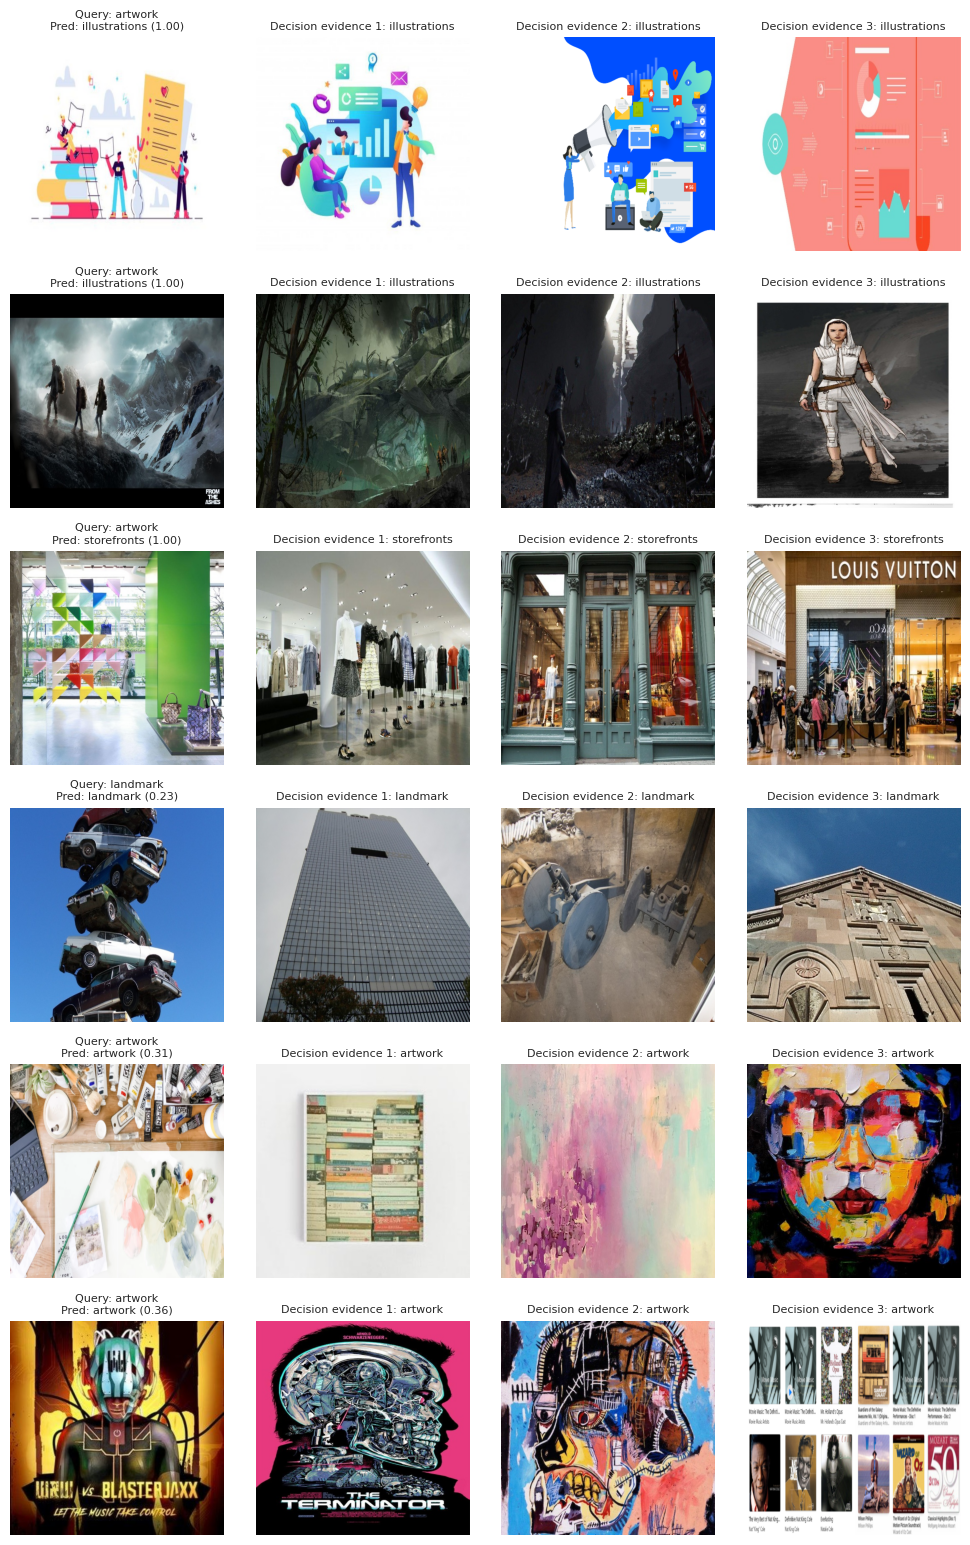

In [13]:
# ruff: noqa: E501, F821 - executed inside the generated notebook namespace

qualitative_rows = []
encoder_key = SELECTED_ENCODER_KEY
seed = int(CFG.seeds[0])
packet = qualitative_bank[(encoder_key, seed)]
memory = primary_memories[(encoder_key, seed)]
labels = packet["labels"]
prediction = packet["prediction"]
confidence = packet["probabilities"].max(1)
correct = prediction == labels
wrong_indices = np.flatnonzero(~correct)
correct_indices = np.flatnonzero(correct)
selected_examples = []
if len(wrong_indices):
    selected_examples.extend(
        wrong_indices[np.argsort(-confidence[wrong_indices])[:3]].tolist()
    )
if len(correct_indices):
    selected_examples.extend(
        correct_indices[np.argsort(confidence[correct_indices])[:3]].tolist()
    )
if not selected_examples:
    selected_examples = np.argsort(confidence)[:6].tolist()

figure, axes = plt.subplots(
    len(selected_examples), 4, figsize=(10, 2.6 * len(selected_examples))
)
axes = np.atleast_2d(axes)
train_frame = SPLIT_FRAMES["train"]
evaluation_frame = SPLIT_FRAMES[EVALUATION_SPLIT]
for row_number, evaluation_index in enumerate(selected_examples):
    query_row = evaluation_frame.iloc[int(evaluation_index)]
    query_path = DATASET_ROOT / query_row["relative_path"]
    axes[row_number, 0].imshow(Image.open(query_path).convert("RGB"))
    axes[row_number, 0].set_title(
        f"Query: {CLASS_NAMES[int(labels[evaluation_index])]}\n"
        f"Pred: {CLASS_NAMES[int(prediction[evaluation_index])]} "
        f"({confidence[evaluation_index]:.2f})",
        fontsize=8,
    )
    selected_prototypes = packet["selected"][int(evaluation_index), :3]
    selected_prototypes = selected_prototypes[selected_prototypes >= 0]
    source_indices = np.asarray(memory["source_idx"], dtype=int)[
        selected_prototypes
    ]
    evidence_labels = np.asarray(memory["labels"], dtype=int)[
        selected_prototypes
    ]
    record = {
        "encoder_key": encoder_key,
        "resolution": int(ENCODER_DATA[encoder_key]["spec"]["resolution"]),
        "evaluation_stage": EVALUATION_STAGE,
        "seed": seed,
        "evaluation_index": int(evaluation_index),
        "query_path": query_row["relative_path"],
        "true_label": CLASS_NAMES[int(labels[evaluation_index])],
        "predicted_label": CLASS_NAMES[int(prediction[evaluation_index])],
        "correct": bool(correct[evaluation_index]),
        "confidence": float(confidence[evaluation_index]),
        "query_reliability": float(
            packet["query_reliability"][evaluation_index]
        ),
        "text_weight": float(packet["text_weight"][evaluation_index]),
        "evidence_scope": "top prototypes within the predicted class",
    }
    for evidence_rank, (source_index, evidence_label) in enumerate(
        zip(source_indices, evidence_labels, strict=True), start=1
    ):
        evidence_row = train_frame.iloc[int(source_index)]
        evidence_path = DATASET_ROOT / evidence_row["relative_path"]
        axes[row_number, evidence_rank].imshow(
            Image.open(evidence_path).convert("RGB")
        )
        axes[row_number, evidence_rank].set_title(
            f"Decision evidence {evidence_rank}: "
            f"{CLASS_NAMES[int(evidence_label)]}",
            fontsize=8,
        )
        record[f"evidence_{evidence_rank}_path"] = evidence_row[
            "relative_path"
        ]
        record[f"evidence_{evidence_rank}_label"] = CLASS_NAMES[
            int(evidence_label)
        ]
    qualitative_rows.append(record)
for axis in axes.ravel():
    axis.axis("off")
figure.tight_layout()
figure.savefig(
    RUN_DIR / f"qualitative_evidence_{encoder_key}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
qualitative_df = pd.DataFrame(qualitative_rows)
atomic_csv(qualitative_df, RUN_DIR / "qualitative_evidence.csv")


## 7. Paper figures, integrity gate, and export

The integrity gate checks manifest balance, complete methods and seeds,
matched budget rows, calibration output, and paired tests. A development run
may select one encoder but cannot unlock final claims. Only a paper-mode run
on the untouched confirmatory split can do that.


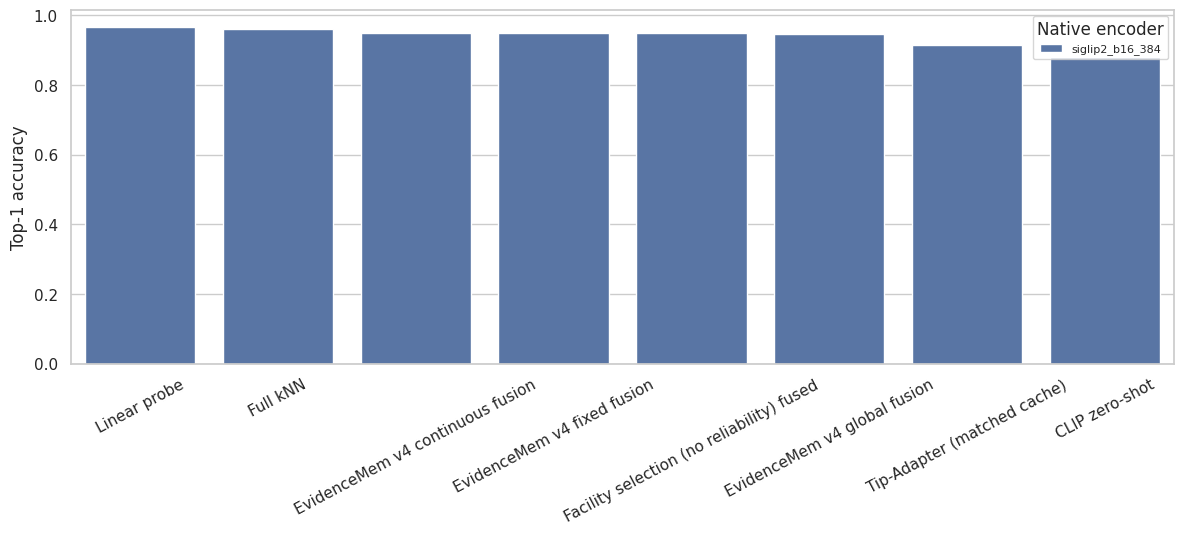

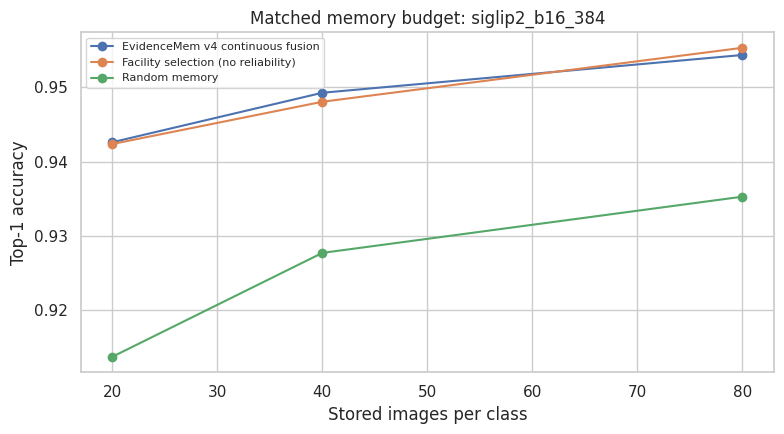

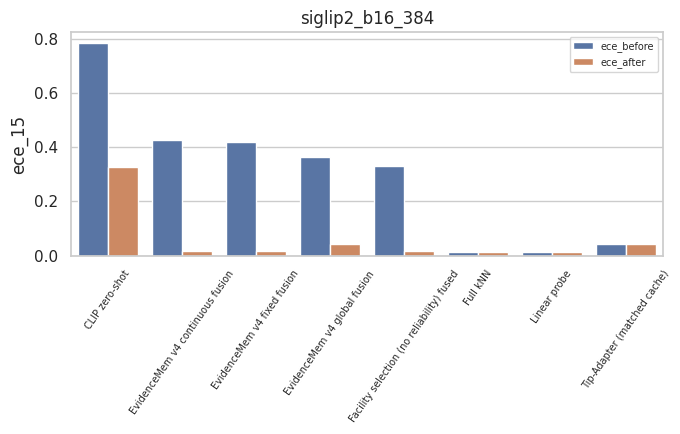

{
  "protocol_id": "uie22k_evidencemem_v4",
  "protocol_revision": "2.0.1",
  "manifest_id": "f9eece5f3f489fd2b986ca89b797c2843e53e2618cd93361b730f0c77bff2c09",
  "mode": "paper",
  "evaluation_stage": "confirmatory",
  "integrity_checks": {
    "confirmatory_stage": true,
    "paper_mode": true,
    "protocol_id_matches_development": true,
    "protocol_revision_matches_development": true,
    "manifest_matches_development": true,
    "package_tree_matches_development": true,
    "encoder_matches_development_selection": true,
    "method_matches_development_selection": true,
    "budget_matches_development_selection": true,
    "sample_seed_matches_development": true,
    "seeds_match_development": true,
    "confirmatory_hypotheses_complete": true,
    "confirmatory_statistics_finite": true,
    "paired_tests_complete": true,
    "manifest_balanced": true,
    "manifest_has_no_exact_duplicates": true,
    "classification_rows_complete": true,
    "method_registry_complete": true,
   

/kaggle/working/EvidenceMem/runs/paper_confirmatory_uie22k_evidencemem_v4_7ce2d2de.zip

In [14]:
# ruff: noqa: E501, F821 - executed inside the generated notebook namespace

selected_methods = [
    "CLIP zero-shot",
    "Full kNN",
    "Linear probe",
    "Facility selection (no reliability) fused",
    "Tip-Adapter (matched cache)",
    "EvidenceMem v4 global fusion",
    "EvidenceMem v4 fixed fusion",
    "EvidenceMem v4 continuous fusion",
]
plot_frame = classification_summary_df[
    classification_summary_df["method"].isin(selected_methods)
].copy()

figure, axis = plt.subplots(figsize=(12, 5.5))
sns.barplot(
    data=plot_frame,
    x="method",
    y="accuracy_mean",
    hue="encoder_key",
    ax=axis,
)
axis.set_xlabel("")
axis.set_ylabel("Top-1 accuracy")
axis.tick_params(axis="x", rotation=28)
axis.legend(title="Native encoder", fontsize=8)
figure.tight_layout()
figure.savefig(RUN_DIR / "main_accuracy.pdf", bbox_inches="tight")
plt.show()

figure, axis = plt.subplots(figsize=(8, 4.5))
for method, group in budget_summary_df.groupby("method"):
    group = group.sort_values("budget_per_class")
    axis.plot(
        group["budget_per_class"],
        group["accuracy_mean"],
        marker="o",
        label=method,
    )
axis.set_xlabel("Stored images per class")
axis.set_ylabel("Top-1 accuracy")
axis.set_title(f"Matched memory budget: {SELECTED_ENCODER_KEY}")
axis.legend(fontsize=8)
figure.tight_layout()
figure.savefig(RUN_DIR / "memory_budget_accuracy.pdf", bbox_inches="tight")
plt.show()

calibration_plot = (
    calibration_summary_df.groupby(["encoder_key", "method"], as_index=False)
    .agg(
        ece_before=("ece_15_uncalibrated", "mean"),
        ece_after=("ece_15", "mean"),
        nll_before=("nll_uncalibrated", "mean"),
        nll_after=("nll", "mean"),
    )
)
calibration_plot = calibration_plot[
    calibration_plot["method"].isin(selected_methods)
]
calibration_long = calibration_plot.melt(
    id_vars=["encoder_key", "method"],
    value_vars=["ece_before", "ece_after"],
    var_name="calibration",
    value_name="ece_15",
)
figure, axes = plt.subplots(
    1,
    len(ENCODER_DATA),
    figsize=(max(7, 5 * len(ENCODER_DATA)), 4.5),
    squeeze=False,
)
for axis, (encoder_key, group) in zip(
    axes.ravel(), calibration_long.groupby("encoder_key"), strict=False
):
    sns.barplot(
        data=group,
        x="method",
        y="ece_15",
        hue="calibration",
        ax=axis,
    )
    axis.set_title(encoder_key)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=55, labelsize=7)
    axis.legend(title="", fontsize=7)
figure.tight_layout()
figure.savefig(RUN_DIR / "calibration_ece.pdf", bbox_inches="tight")
plt.show()

v4_summary = classification_summary_df[
    classification_summary_df["method"]
    == "EvidenceMem v4 continuous fusion"
].set_index("encoder_key")
result_summary = {
    "evaluation_stage": EVALUATION_STAGE,
    "evaluation_split": EVALUATION_SPLIT,
    "selected_encoder_key": SELECTED_ENCODER_KEY,
    "accuracy_by_encoder": {
        str(index): float(row["accuracy_mean"])
        for index, row in v4_summary.iterrows()
    },
    "macro_f1_by_encoder": {
        str(index): float(row["macro_f1_mean"])
        for index, row in v4_summary.iterrows()
    },
    "ece_by_encoder": {
        str(index): float(row["ece_mean"])
        for index, row in v4_summary.iterrows()
    },
}

expected_classification_rows = (
    len(ENCODER_DATA) * len(CFG.seeds) * len(MAIN_METHODS)
)
expected_split_counts = {
    "train": CFG.train_per_class,
    "val": CFG.val_per_class,
    "development": CFG.development_per_class,
    "confirmatory": CFG.confirmatory_per_class,
}
observed_split_counts = (
    manifest_df.groupby(["label", "split"]).size().unstack(fill_value=0)
)
manifest_balanced = (
    set(observed_split_counts.index) == set(CLASS_NAMES)
    and set(observed_split_counts.columns) == set(expected_split_counts)
    and all(
        int(observed_split_counts.at[class_name, split_name])
        == expected_count
        for class_name in CLASS_NAMES
        for split_name, expected_count in expected_split_counts.items()
    )
)
expected_method_paired_tests = len(ENCODER_DATA) * len(CFG.seeds) * 6
expected_encoder_paired_tests = (
    (len(ENCODER_DATA) - 1) * len(CFG.seeds)
    if "clip_b32_224" in ENCODER_DATA
    else 0
)
expected_paired_tests = expected_method_paired_tests + expected_encoder_paired_tests
expected_hypothesis_ids = {
    item["id"] for item in FROZEN_DEVELOPMENT_RECORD["confirmatory_hypotheses"]
}
hypothesis_numeric_columns = [
    "accuracy_delta",
    "ci_low",
    "ci_high",
    "bootstrap_p_two_sided",
    "seed_sign_flip_p_two_sided",
]

integrity_checks = {
    **FROZEN_PROTOCOL_CHECKS,
    "confirmatory_hypotheses_complete": (
        set(CONFIRMATORY_HYPOTHESES["hypothesis_id"])
        == expected_hypothesis_ids
    ),
    "confirmatory_statistics_finite": bool(
        np.isfinite(
            CONFIRMATORY_HYPOTHESES[hypothesis_numeric_columns].to_numpy(
                dtype=float
            )
        ).all()
    ),
    "paired_tests_complete": len(paired_results) == expected_paired_tests,
    "manifest_balanced": bool(manifest_balanced),
    "manifest_has_no_exact_duplicates": not bool(
        manifest_df["sha256"].duplicated().any()
    ),
    "classification_rows_complete": len(classification_df)
    == expected_classification_rows,
    "method_registry_complete": set(classification_df["method"])
    == set(MAIN_METHODS),
    "all_seeds_complete": classification_df["seed"].nunique()
    == len(CFG.seeds),
    "all_encoders_complete": set(classification_df["encoder_key"])
    == set(ENCODER_DATA),
    "paired_tests_present": len(paired_results) > 0,
    "budget_rows_complete": len(budget_df)
    == len(CFG.seeds) * len(CFG.budgets) * 3,
    "calibration_rows_complete": len(calibration_summary_df)
    == expected_classification_rows,
}
run_complete = all(integrity_checks.values())
claim_gate = {
    "protocol_id": PROTOCOL_ID,
    "protocol_revision": PROTOCOL_REVISION,
    "manifest_id": MANIFEST_ID,
    "mode": CFG.mode,
    "evaluation_stage": EVALUATION_STAGE,
    "integrity_checks": integrity_checks,
    "run_complete": run_complete,
    "ready_for_development_selection": run_complete
    and CFG.mode == "paper"
    and EVALUATION_STAGE == "development",
    "ready_for_final_claims": run_complete
    and CFG.mode == "paper"
    and EVALUATION_STAGE == "confirmatory",
    "result_summary": result_summary,
    "frozen_development_record": FROZEN_DEVELOPMENT_RECORD,
    "confirmatory_hypotheses": CONFIRMATORY_HYPOTHESES.to_dict(
        orient="records"
    ),
    "hypothesis_support": {
        str(row["hypothesis_id"]): bool(row["supported"])
        for row in CONFIRMATORY_HYPOTHESES.to_dict(orient="records")
    },
    "warning": (
        "Development results may select one encoder but are not final evidence. "
        "Freeze the selected key before the confirmatory run."
        if EVALUATION_STAGE == "development"
        else "Confirmatory results are valid only if no tuning follows this run."
    ),
}
atomic_json(RUN_DIR / "claim_gate.json", claim_gate)
if not run_complete:
    failed = [name for name, passed in integrity_checks.items() if not passed]
    raise RuntimeError(f"Run integrity gate failed: {failed}")

required_artifacts = [
    "uie22k_manifest.csv",
    "frozen_protocol.json",
    "confirmatory_hypotheses.csv",
    "confirmatory_hypotheses.json",
    "sampling_summary.json",
    "environment.json",
    "encoder_runtime.csv",
    "classification_results.csv",
    "classification_summary.csv",
    "calibration_summary.csv",
    "fusion_topk_validation.csv",
    "reliability_tuning.csv",
    "selected_hyperparameters.json",
    "development_selection.json",
    "paired_tests.json",
    "encoder_deltas.csv",
    "memory_budget_results.csv",
    "memory_budget_summary.csv",
    "qualitative_evidence.csv",
    "main_accuracy.pdf",
    "memory_budget_accuracy.pdf",
    "calibration_ece.pdf",
    "claim_gate.json",
]
completed_manifest = finalize_run_manifest(
    RUN_MANIFEST,
    run_directory=RUN_DIR,
    required_artifacts=required_artifacts,
)
atomic_write_json(RUN_DIR / "run_manifest.json", completed_manifest)
archive_path = Path(
    shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
)
journal("run_complete", archive=str(archive_path), results=result_summary)
print(json.dumps(claim_gate, indent=2))
print("Complete artifact directory:", RUN_DIR)
print("Downloadable archive:", archive_path)
try:
    from IPython.display import FileLink, display

    display(FileLink(str(archive_path)))
except Exception:
    pass
